
## 5G NR MIB and SIB1 Recovery

Before a mobile station (UE) can communicate with a 5G base station (gNodeB), it must first find the cell (cell ID), synchronize (time and frequency) with it, and read some basic information (MIB and SIB1).


To do this, it decodes two key messages:

-  MIB (Master Information Block) \- provides fundamental parameters required to access the network.
-  SIB1 (System Information Block Type 1) \- provides additional system configuration needed for the initial connection.

This implementation shows how a 5G receiver synchronizes and decodes these messages.

### A. Transmitter Side (Signal Generation)
-  The base station periodically transmits a Synchronization Signal Block (SSB).
-  Each SSB includes \- Primary Synchronization Signal (PSS), Secondary Synchronization Signal (SSS), and Physical Broadcast Channel (PBCH) which carries the MIB.
-  The SIB1 is carried on PDSCH (Physical Downlink Shared Channel).
### B. Wireless Channel (AWGN)
-  The signal is passed through a wireless channel with Additive White Gaussian Noise (AWGN).
-  Mathematically, the received signal is: r\[n\] = x\[n\] + w\[n\], where r\[n\] = received signal, x\[n\] = transmitted signal, w\[n\] = random noise with Gaussian distribution.
### C. Receiver Side

The receiver performs the following tasks:

-  Synchronization: Aligns timing and frequency using PSS and SSS.
-  Cell Identification: Determines the cell ID (NCellID) from detected PSS/SSS.
-  Demodulation: Demodulates PBCH to obtain the MIB.
-  Decoding: Uses the MIB information to decode PDCCH, PDSCH, and finally recover SIB1.

To synchronize and demodulate the received signal, receiver needs the following parameters to process the received waveform correctly:

| **Parameter** <br>  | **Meaning** <br>  | **Purpose** <br>   |
| :-- | :-- | :-- |
| Sample Rate <br>  | Number of samples per second <br>  | Used for OFDM demodulation and timing <br>   |
| Carrier Frequency (fPhaseComp) <br>  | RF center frequency of transmission <br>  | Used to correct phase rotation in received samples <br>   |
| MinChannelBW <br>  | Minimum allowed bandwidth (5, 10, or 40 MHz) <br>  | Helps determine CORESET 0 (control region) <br>   |
| SS Block Pattern <br>  | Defines SSB frequency and subcarrier spacing (Cases A\-E) <br>  | Helps decide search range and spacing <br>   |
| L\_max <br>  | Maximum number of SS/PBCH blocks (4, 8, or 64) in SS burst <br>  | Used for PBCH DMRS and descrambling <br>   |

### A. Generate Signal containing SS burst and SIB1

First, create an SS burst containing multiple SSBs at different symbol indices. Then generate SIB1, and finally generate the waveform containing both the SS burst and SIB1.

#### 1. SS Burst

An SS burst contains multiple SSB patterns (Case A \- Case G) depending on subcarrier spacing and carrier frequency range. It has a duration equal to half frame (5 subframe or 5 ms) and maximum number of SSBs per half frame depends on operating frequency band.

#### Generate SSB

An SSB occupies 240 subcarriers in frequency and 4 OFDM symbols in time. It is a self\-synchronization block containing PSS, SSS, PBCH, and PBCH\-DMRS, where the PBCH carries the MIB information. These components are transmitted in a specific pattern where PSS goes in first symbol SSB, SSS goes in 3rd symbol and PBCH along with DMRS goes in 2nd, 3rd, and 4th symbols.

#### Primary Synchronization Signal (PSS)

PSS is the first downlink used for radio synchronization. It helps UE to find out symbol boundary and helps UE to find out cell ID. It is generated using m\-sequence,  and occupies 127 subcarriers in frequency and 1 OFDM symbol in time.


$$\textrm{CellID}=3\cdot N_{\textrm{ID}\;}^1 +N_{\textrm{ID}\;\;}^2 ,\textrm{where}\;\textrm{CellID}\in \left\lbrace 0,1,2,\cdots 1007\right\rbrace$$

$${N_{\textrm{ID}}^2 \in \left\lbrace 0,1,\cdots 335\right\rbrace \;\textrm{and}\;N}_{\textrm{ID}}^2 \in \left\lbrace 0,1,2\right\rbrace$$

To achieve time synchronization, the gNodeB transmits the PSS signal. The UE locally generates all three possible PSS sequences and correlates them with the received signal. When the correlation exceeds a predefined threshold, it indicates the correct symbol timing.

#### Generate m\-sequence

This is a binary sequence of length 127. It is produced using the relation:


$$x(i+7)=\bigl(x(i+4)+x(i)\bigr)\textrm{mod}2$$

Initial state: $[x(6)\;x(5)\;x(4)\;x(3)\;x(2)\;x(1)\;x(0)]=[1,1,1,0,1,1,0]$


(Here $x(0)$ is the LSB).


After the initial 7 bits, each new $x(i)$ is computed as:


$$x(i)=(x(i-3)+x(i-7))\textrm{mod}2$$
#### Compute $m(n)$

For each $n=0,1,\ldots,126$:


$$m(n)=(n+43\cdot N_{ID}^2 )\textrm{mod}127$$

where $N_{ID}^2 \in \lbrace 0,1,2\rbrace$

#### Map to $d_{\textrm{PSS}} (n)$

Finally computes:


$$d_{\textrm{PSS}} (n)=1-2\cdot x\bigl(m(n)\bigr)$$

This maps:


$$x(m(n))=0\;\;\to \;\;d_{\textrm{PSS}} (n)=+1\;\,$$

$$x(m(n))=1\;\;\to \;\;d_{\textrm{PSS}} (n)=-1\;$$

This is a BPSK\-mapped sequence that is transmitted as the PSS sequence in 5G NR as per TS 38.211 by 3GPP.


In [1]:
% generate a 240×4 matrix to represent the SS/PBCH block
ssb = zeros([240 4])

ssb = 240x4
     0     0     0     0
     0     0     0     0
     0     0     0     0
     0     0     0     0
     0     0     0     0
     0     0     0     0
     0     0     0     0
     0     0     0     0
     0     0     0     0
     0     0     0     0
     0     0     0     0
     0     0     0     0
     0     0     0     0
     0     0     0     0
     0     0     0     0


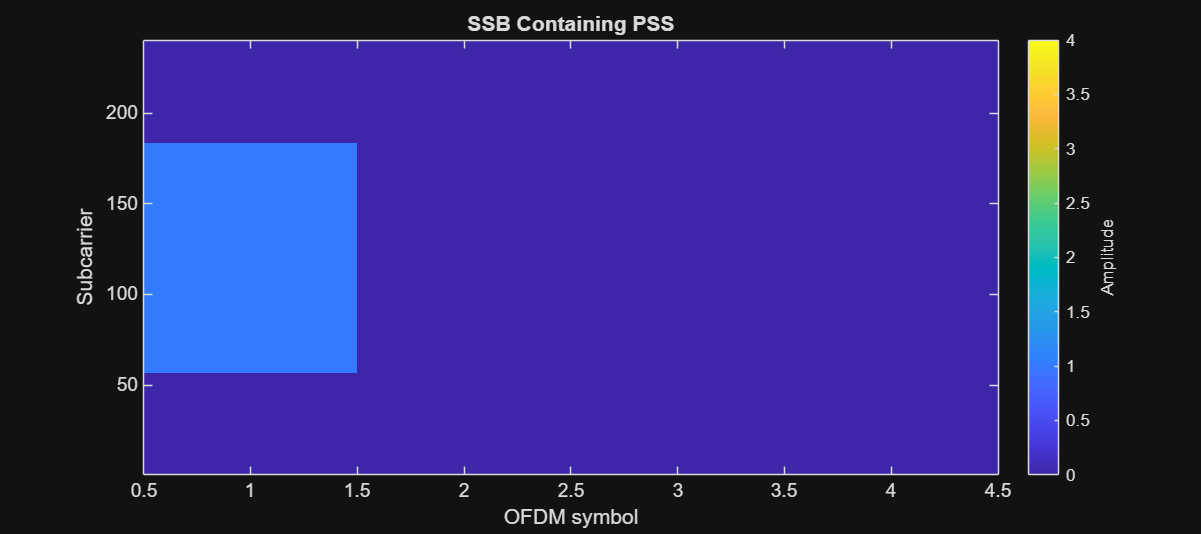

In [2]:
% generate PSS and PSS indices for a given cellID

cellID = 1;                  % Cell ID
pss = nrPSS(cellID);         % PSS sequence
pss_indices = nrPSSIndices;  % PSS sequence indices

% map the PSS into SSB
ssb(pss_indices) = 1 * pss;  % scale by beta=1 as per TS 38.211 Section 7.4.3.1.1

% plot the SSB containing PSS
figure('Position', [100 100 900 400])
imagesc(abs(ssb));
clim([0 4])
axis xy;
title('SSB Containing PSS');
ylabel('Subcarrier');
xlabel('OFDM symbol');

c = colorbar;
c.Label.String = 'Amplitude';

#### Secondary Synchronization Signal (SSS)

It is same as PSS, takes 127 subcarriers in frequency and 1 OFDM symbol in time. It is always transmitted as a part of SSB along with PSS. SSS along with PSS helps UE to find cell ID and do frame synchronization. It is generated using m\-sequence.

#### Compute $m_0$ and $m_1$

$$m_0 =15\cdot \left\lfloor \frac{N_{ID}^1 }{112}\right\rfloor +5\cdot N_{ID}^2$$

$$m_1 =N_{ID}^1 \textrm{mod}112$$

 $m_0$ and $m_1$ define the cyclic shifts for $x_0$ and $x_1$.

#### Generate m\-sequence $x_0 (i)$

$$x_0 (i+7)=\bigl(x_0 (i)+x_0 (i+4)\bigr)\textrm{mod}2$$

Initial state: $[x_0 (6)\;x_0 (5)\;x_0 (4)\;x_0 (3)\;x_0 (2)\;x_0 (1)\;x_0 (0)]=[0,0,0,0,0,0,1]$

#### Generate m\-sequence $x_1 (i)$

$$x_1 (i+7)=\bigl(x_1 (i+1)+x_1 (i)\bigr)\textrm{mod}2$$

same initial state as $x_0 (i)$.

#### Compute $m_0 (n)$ and $m_1 (n)$

For each $n=0,1,\ldots,126$:


$$m_0 (n)=(n+m_0 )\textrm{mod}127$$

$$m_1 (n)=(n+m_1 )\textrm{mod}127$$
#### Generate $d_{SSS} (n)$

$$dSSS(n)=\bigl(1-2\cdot x_0 (m_0 (n))\bigr)\cdot \bigl(1-2\cdot x_1 (m_1 (n))\bigr)$$

This performs BPSK mapping, where:


$$x₀(m₀(n)),x₁(m₁(n))=0\to \;\textrm{contributes}\;\textrm{+1}$$

$$x₀(m₀(n)),x₁(m₁(n))=1\to \;\textrm{contributes}\;\textrm{-}\textrm{1}$$


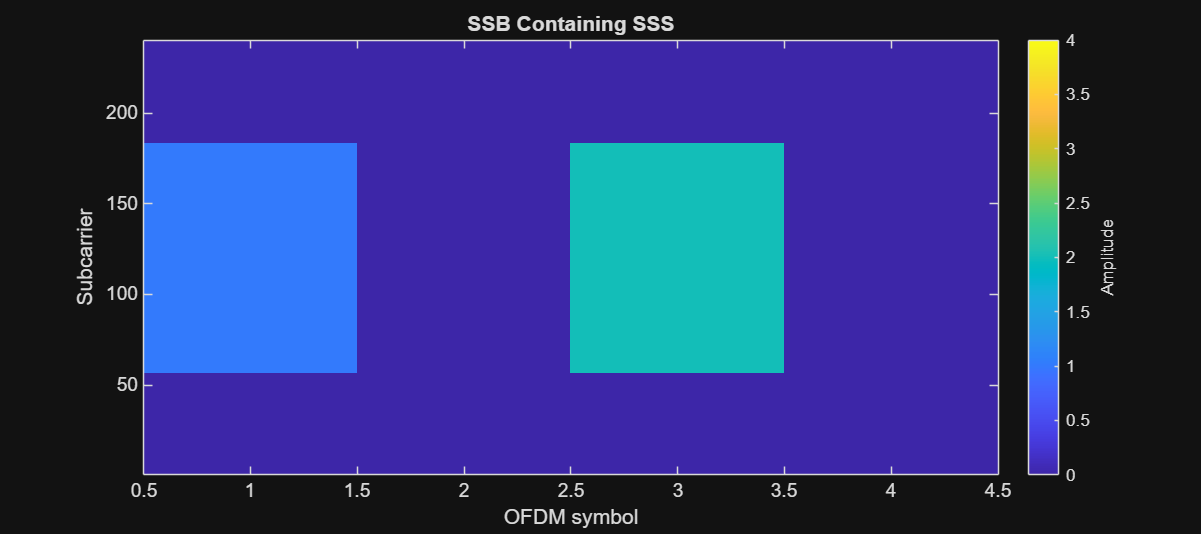

In [3]:
% generate the SSS and its indices and map it into SSB
sss = nrSSS(cellID);                 % SSS sequence
sss_indices = nrSSSIndices;         % SSS sequence indices
ssb(sss_indices) = 2 * sss;         % map the SSS, scaled by beta=2 as per TS 38.211 Section 7.4.3.1.1

% plot SSS
figure('Position', [100 100 900 400])
imagesc(abs(ssb));
clim([0 4])
axis xy;
title('SSB Containing SSS');
ylabel('Subcarrier');
xlabel('OFDM symbol');

c = colorbar;
c.Label.String = 'Amplitude';

#### Physical Broadcast Channel (PBCH)

PBCH carries the Master Information Block (MIB). In the 3GPP standard, the short MIB payload is CRC\-appended, then polar coded and rate\-matched into an 864\-bit codeword that is finally QPSK\-mapped and placed across the PBCH REs inside the SSB.


PBCH modulation consists of the following steps:

#### 1. Scrambling

Bits are scrambled according to:


$$\bar{b} (i)=\bigl(b(i)+c(i+vM_{\textrm{bit}} )\bigr)\textrm{mod}2$$

where:


 $b(i)$ is the input bit sequence.


 $c(i)$ is the scrambling sequence as defined in 3GPP TS 38.211.


 $M_{\textrm{bit}}$ is the number of bits transmitted on the physical broadcast channel.


 $v$ is 2 or 3 LSBs of SSB block index.

#### 2. Modulation

The scrambled bits $\bar{b} (i)$ are QPSK modulated as per 3GPP TS 38.211.


$$d(i)=\frac{1}{\sqrt{2}}\left\lbrack (1-2b(2i))+j(1-2b(2i+1))\right\rbrack$$
#### 3. Mapping

PBCH is mapped across time/frequency as follows:


OFDM symbol 1 → subcarriers $k=0\ldots239$


OFDM symbol 3 → subcarriers $k=0\ldots239$


OFDM symbol 2 → edge ranges $k=0\ldots47$ and $k=192\ldots239\,$



In [4]:
% consider a codeword and take v = 0

codeword = randi([0, 1], 864, 1);     % take random some random bits
v = 0

v = 0


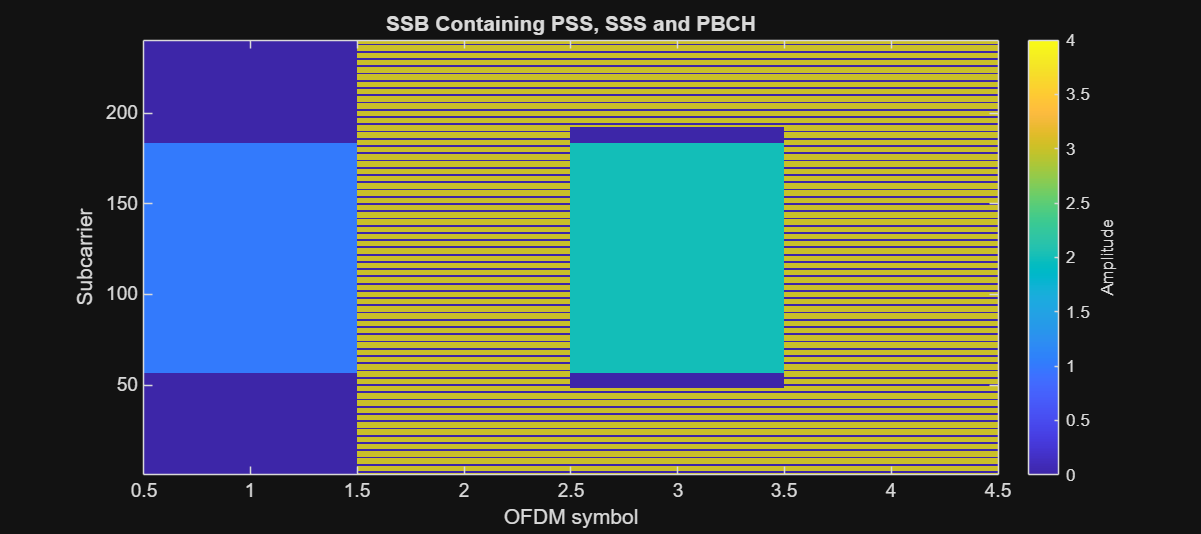

In [5]:
pbch = nrPBCH(codeword, cellID, v);   % PBCH sequence
pbch_indices = nrPBCHIndices(cellID); % PBCH indices
ssb(pbch_indices) = 3 * pbch;         % map the PBCH, scaled by beta=3 as per TS 38.211 Section 7.4.3.1.1

% plot the PBCH into SSB
figure('Position', [100 100 900 400])
imagesc(abs(ssb));
clim([0 4])
axis xy;
title('SSB Containing PSS, SSS and PBCH');
ylabel('Subcarrier');
xlabel('OFDM symbol');

c = colorbar;
c.Label.String = 'Amplitude';

#### **PBCH Demodulation Reference Signal (PBCH DM\-RS)**

DMRS is a 144\-symbol sequence (per SSB) that depends on the Cell ID and the time index part ${\bar{i} }_{SSB}$ (SSB index).


The UE shall assume the reference\-signal sequence $r(m)$ for an SSB is defined by


$$r(m)=\frac{1}{\sqrt{2}}\Bigl\lbrack \bigl(1-2\cdot c(2m)\bigr)+j\cdot \bigl(1-2\cdot c(2m+1)\bigr)\Bigr\rbrack$$

where $c(n)$ is the scrambling sequence.




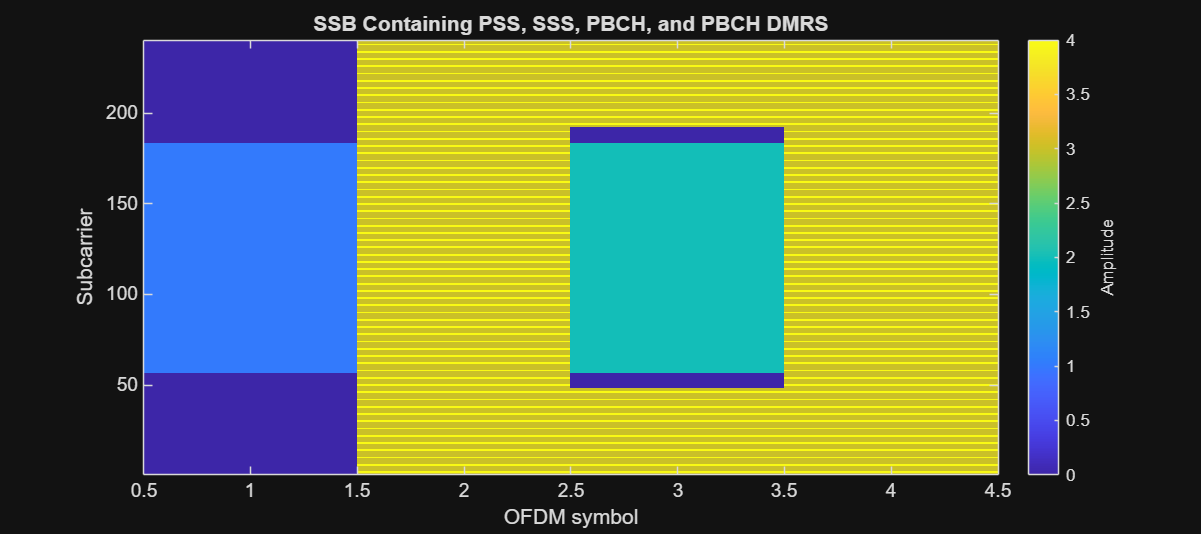

In [6]:
% consider ibar_ssb = 0

ibar_ssb = 0;                                  % initialize ibar_ssb
pbch_dmrs = nrPBCHDMRS(cellID, ibar_ssb);      % generate DMRS
pbch_dmrs_indices = nrPBCHDMRSIndices(cellID); % get DMRS indices for PBCH
ssb(pbch_dmrs_indices) = 4 * pbch_dmrs;        % map the PBCH DMRS into SSB, scaled by beta=4

% plot PBCH DMRS into SSB
figure('Position', [100 100 900 400])
imagesc(abs(ssb));
clim([0 4])
axis xy;
title('SSB Containing PSS, SSS, PBCH, and PBCH DMRS');
ylabel('Subcarrier');
xlabel('OFDM symbol');

c = colorbar;
c.Label.String = 'Amplitude';

#### SS Burst

An SS burst is composed of multiple SSBs and occupies half of a radio frame, which corresponds to five subframes.

#### Frame and Slot Structure (TS 38.211 §4.3.1)

One frame = 10 subframes (each of 1 ms).


One slot = 14 OFDM symbols (for normal CP).


The number of slots per subframe depends on the subcarrier spacing (SCS).

#### Subcarrier Spacing

Subcarrier spacing is defined by the numerology $\mu$


$$\textrm{SCS}=15\,\textrm{kHz}\cdot 2^{\mu }$$
#### Total Number of OFDM Symbols in an SS Burst

The number of OFDM symbols contained in an SS burst is:


$$N_{\textrm{symbols}} =\textrm{(symbols}\;\textrm{per}\;\textrm{slot)}\cdot 2^{\mu } \cdot N_{\textrm{subframes}}$$

$$N_{\textrm{symbols}} =\textrm{14}\cdot 2^{\mu } \cdot 5$$

For $\mu =1,$ $N_{\textrm{symbols}} =\textrm{140}$

#### SSB Pattern Inside the SS Burst

The maximum number of beams $L_{\max }$ depends on the operating band:


$$\textrm{Op.}\;\textrm{Band}\le 3\,\textrm{GHz}\;\;\Rightarrow \;\;L_{\max } =4\;\,$$

$$3\,\textrm{GHz}<\textrm{Op.}\;\textrm{Band}\le 6\,\textrm{GHz}\;\;\Rightarrow \;\;L_{\max } =8\;\,$$

$$\textrm{Op.}\;\textrm{Band}>6\,\textrm{GHz}\;\;\Rightarrow \;\;L_{\max } =64\;\,$$

Each beam transmits one SSB, and each beam is identified by an SS block index.


Block Patterns in FR1 (Sub\-6 GHz) \- Here, $L_{\max } =4\;\textrm{or}\;8$.

#### Case A – 15 KHz SCS

The first symbols of the candidate SS/PBCH blocks have indexes of $[2,8]+14*n$


For operation without shared spectrum channel access:

-  For carrier frequencies ≤ 3 GHz, $n=0,1$
-  For carrier frequencies within FR1 and > 3 GHz, $n=0,1,2,3$

For operation with shared spectrum channel access (as described in 3GPP TS 37.213):

-  $\displaystyle n=0,1,2,3,4$

Parameters $i_{SSB} \textrm{,}\;{\bar{i} }_{SSB}$, and $v$ are set up according to the rules in 3GPP TS 38.211 Sections 7.3.3.1 and 7.4.1.4.1


For $L_{\max } =4\textrm{,}\;{\bar{i} }_{SSB} =i_{SSB} +4n_{hf}$ where $n_{\textrm{hf}}$ is the number of the half\-frame in which the PBCH is transmitted in a frame, with $n_{\textrm{hf}} =0$ for the first half\-frame and $n_{\textrm{hf}} =1$ for the second half\-frame, and $i_{SSB}$ represents the two least significant bits of the candidate SS/PBCH block index as defined in 3GPP TS 38.213.


For $L_{\max } >4\textrm{,}\;{\bar{i} }_{SSB} =i_{SSB} \;\textrm{and}\;v=i_{SSB} \;\textrm{where}\;i_{SSB}$ is the three least significant bits of the candidate SS/PBCH block.


In [7]:
%{
*----- fc <= 3GHz -----*

Lmax  = 4
v     = 2 LSBs of candidate SS/PBCH block index (TS 38.211 §7.3.3.1)
i_ssb = 2 LSBs of candidate SS/PBCH block index (TS 38.211 §7.4.1.4.1)
n_hf  = 0 as all SSBs are in the first half-frame
n     = 0, 1

%}

n_hf = 0;                   % Half-frame number
mu = 0;                     % mu = 0 → 15 kHz SCS
n_subframe = 5;             % total subframes in the SS burst
symbols_per_slot = 14;      % total OFDM symbols per slot
total_symbols = symbols_per_slot * 2^mu * n_subframe;
ss_burst_A1 = zeros([240 total_symbols]);

n = [0, 1];
first_symbol_index_ssb = [2; 8] + 14 * n;
first_symbol_index_ssb = first_symbol_index_ssb(:).'

first_symbol_index_ssb = 1x4
     2     8    16    22


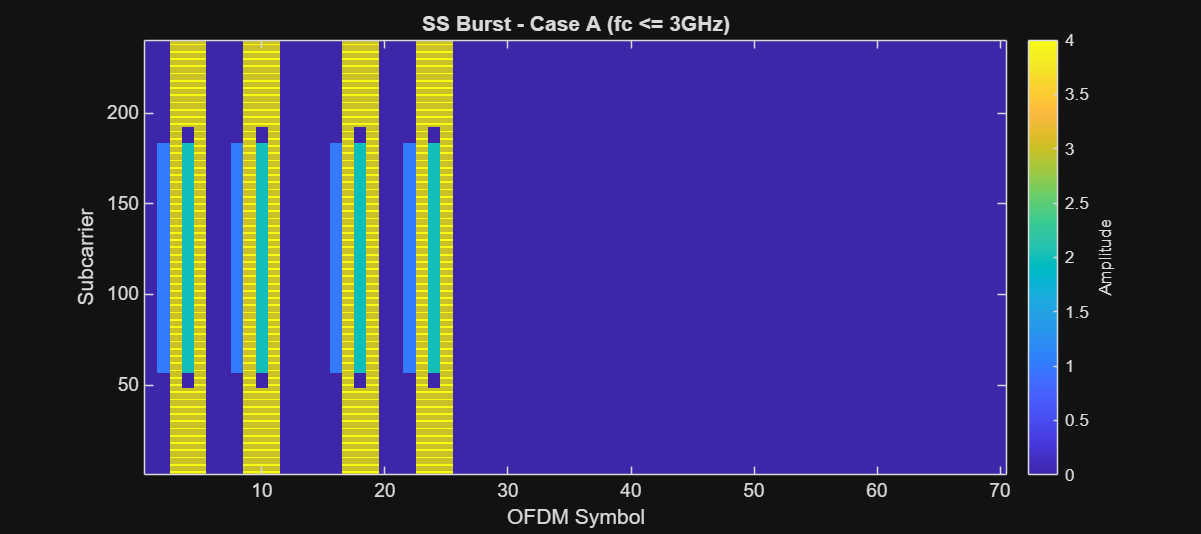

In [8]:

for ssb_index = 1:length(first_symbol_index_ssb)
    v = mod(ssb_index-1, 4);
    issb = mod(ssb_index-1, 4);
    ibar_ssb = issb + 4 * n_hf;

    pbch = nrPBCH(codeword, cellID, v);
    ssb(pbch_indices) = 3 * pbch;

    pbch_dmrs = nrPBCHDMRS(cellID, ibar_ssb);
    ssb(pbch_dmrs_indices) = 4 * pbch_dmrs;

    ss_burst_A1(:, first_symbol_index_ssb(ssb_index) + (0:3)) = ssb;
end

% plot the SS burst
figure('Position', [100 100 900 400])
imagesc(abs(ss_burst_A1));
clim([0 4])
axis xy;
title('SS Burst - Case A (fc <= 3GHz)');
ylabel('Subcarrier');
xlabel('OFDM Symbol');

c = colorbar;
c.Label.String = 'Amplitude';

In [9]:
%{
*----- 3GHz < fc <= 6GHz -----*

Lmax  = 8
v     = 3 LSBs of candidate SS/PBCH block index (TS 38.211 §7.3.3.1)
i_ssb = 3 LSBs of candidate SS/PBCH block index (TS 38.211 §7.4.1.4.1)
n_hf  = 0 as all SSBs are in the first half-frame
n     = 0, 1, 2, 3

%}

mu = 0;
n_subframe = 5;
symbols_per_slot = 14;
total_symbols = symbols_per_slot * 2^mu * n_subframe;
ss_burst_A2 = zeros([240 total_symbols]);

n = [0, 1, 2, 3];
first_symbol_index_ssb = [2; 8] + 14 * n;
first_symbol_index_ssb = first_symbol_index_ssb(:).'

first_symbol_index_ssb = 1x8
     2     8    16    22    30    36    44    50


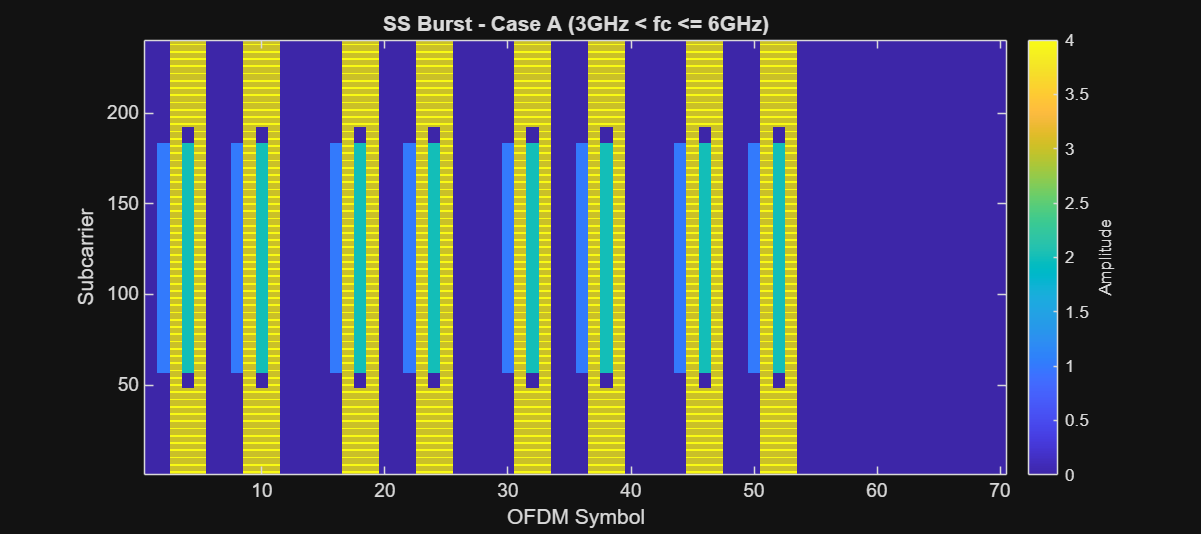

In [10]:

for ssb_index = 1:length(first_symbol_index_ssb)
    v = mod(ssb_index-1, 8);
    issb = v;
    ibar_ssb = issb;

    pbch = nrPBCH(codeword, cellID, v);
    ssb(pbch_indices) = 3 * pbch;

    pbch_dmrs = nrPBCHDMRS(cellID, ibar_ssb);
    ssb(pbch_dmrs_indices) = 4 * pbch_dmrs;

    ss_burst_A2(:, first_symbol_index_ssb(ssb_index) + (0:3)) = ssb;
end

% plot the SS burst
figure('Position', [100 100 900 400])
imagesc(abs(ss_burst_A2));
clim([0 4])
axis xy;
title('SS Burst - Case A (3GHz < fc <= 6GHz)');
ylabel('Subcarrier');
xlabel('OFDM Symbol');

c = colorbar;
c.Label.String = 'Amplitude';

#### Case B – 30 KHz SCS

The first symbols of the candidate SS/PBCH blocks have indexes of $[4,8,16,20]+28*n$

-  For carrier frequencies ≤ 3 GHz, $n=0$
-  For carrier frequencies within FR1 and > 3 GHz, $n=0,1$

In [11]:
%{
*----- fc <= 3GHz -----*

Lmax  = 4
v     = 2 LSBs of candidate SS/PBCH block index (TS 38.211 §7.3.3.1)
i_ssb = 2 LSBs of candidate SS/PBCH block index (TS 38.211 §7.4.1.4.1)
n_hf  = 0 as all SSBs are in the first half-frame
n     = 0

%}

n_hf = 0;
mu = 1;
n_subframe = 5;
symbols_per_slot = 14;
total_symbols = symbols_per_slot * 2^mu * n_subframe;
ss_burst_B1 = zeros([240 total_symbols]);

n = 0;
first_symbol_index_ssb = [4; 8; 16; 20] + 28 * n;
first_symbol_index_ssb = first_symbol_index_ssb(:).'

first_symbol_index_ssb = 1x4
     4     8    16    20


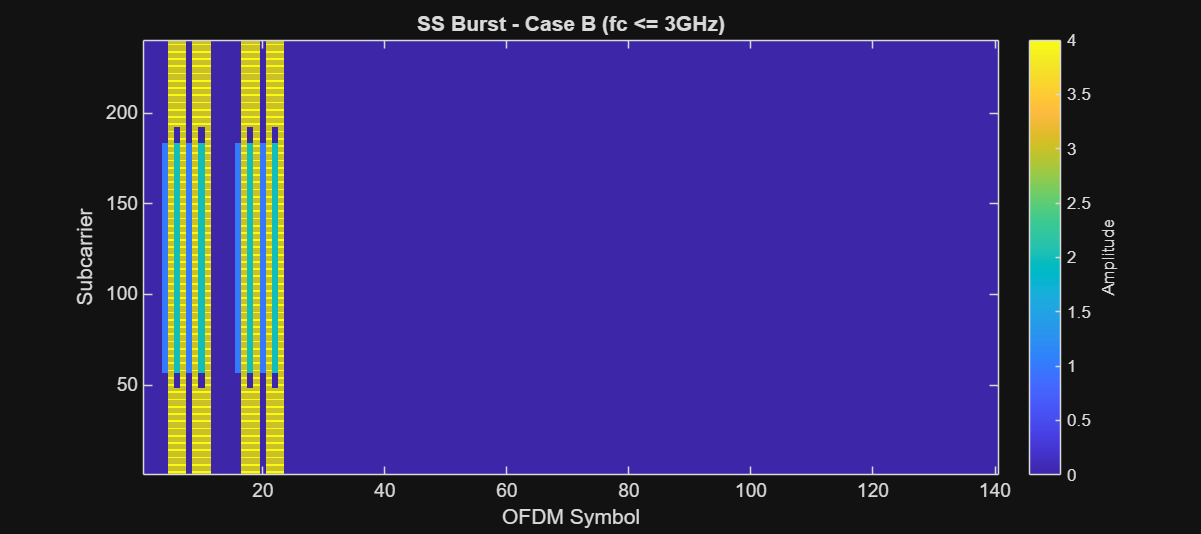

In [12]:

for ssb_index = 1:length(first_symbol_index_ssb)
    v = mod(ssb_index-1, 4);
    issb = mod(ssb_index-1, 4);
    ibar_ssb = issb + 4 * n_hf;

    pbch = nrPBCH(codeword, cellID, v);
    ssb(pbch_indices) = 3 * pbch;

    pbch_dmrs = nrPBCHDMRS(cellID, ibar_ssb);
    ssb(pbch_dmrs_indices) = 4 * pbch_dmrs;

    ss_burst_B1(:, first_symbol_index_ssb(ssb_index) + (0:3)) = ssb;
end

% plot the SS burst
figure('Position', [100 100 900 400])
imagesc(abs(ss_burst_B1));
clim([0 4])
axis xy;
title('SS Burst - Case B (fc <= 3GHz)');
ylabel('Subcarrier');
xlabel('OFDM Symbol');

c = colorbar;
c.Label.String = 'Amplitude';

In [13]:
%{
*----- 3MHz < fc <= 6GHz -----*

Lmax  = 8
v     = 3 LSBs of candidate SS/PBCH block index (TS 38.211 §7.3.3.1)
i_ssb = 3 LSBs of candidate SS/PBCH block index (TS 38.211 §7.4.1.4.1)
n_hf  = 0 as all SSBs are in the first half-frame
n     = 0, 1

%}

mu = 1;
n_subframe = 5;
symbols_per_slot = 14;
total_symbols = symbols_per_slot * 2^mu * n_subframe;
ss_burst_B2 = zeros([240 total_symbols]);

n = [0, 1];
first_symbol_index_ssb = [4; 8; 16; 20] + 28 * n;
first_symbol_index_ssb = first_symbol_index_ssb(:).'

first_symbol_index_ssb = 1x8
     4     8    16    20    32    36    44    48


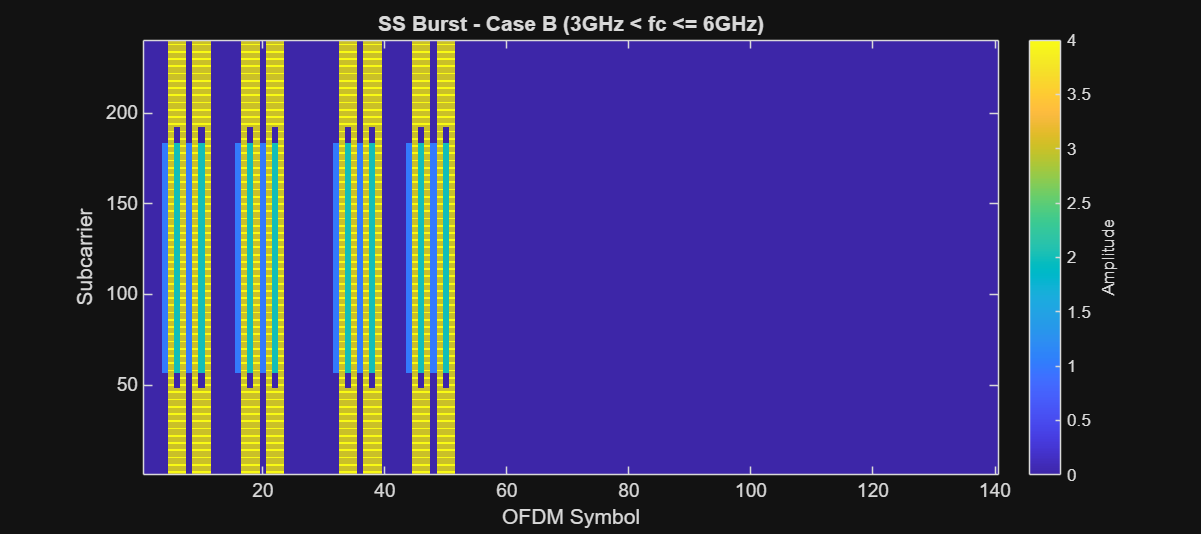

In [14]:

for ssb_index = 1:length(first_symbol_index_ssb)
    v = mod(ssb_index-1, 8);
    issb = v;
    ibar_ssb = issb;

    pbch = nrPBCH(codeword, cellID, v);
    ssb(pbch_indices) = 3 * pbch;

    pbch_dmrs = nrPBCHDMRS(cellID, ibar_ssb);
    ssb(pbch_dmrs_indices) = 4 * pbch_dmrs;

    ss_burst_B2(:, first_symbol_index_ssb(ssb_index) + (0:3)) = ssb;
end

% plot the SS burst
figure('Position', [100 100 900 400])
imagesc(abs(ss_burst_B2));
clim([0 4])
axis xy;
title('SS Burst - Case B (3GHz < fc <= 6GHz)');
ylabel('Subcarrier');
xlabel('OFDM Symbol');

c = colorbar;
c.Label.String = 'Amplitude';

#### Case C \- 30 KHz SCS

The first symbols of the candidate SS/PBCH blocks have indexes: $[2,8]+14*n$


Operation without shared spectrum channel access


Paired spectrum operation:

-  For carrier frequencies ≤ 3 GHz → $n=0,1$
-  For carrier frequencies within FR1 and > 3 GHz → $n=0,1,2,3$

Unpaired spectrum operation:

-  For carrier frequencies < 1.88 GHz → $n=0,1\;$
-  For carrier frequencies within FR1 and ≥ 1.88 GHz → $n=0,1,2,3$

Operation with shared spectrum channel access:

-  $\displaystyle n=0,1,2,3,4,5,6,7,8,9$

In [15]:
%{
*----- fc <= 3GHz -----*

Lmax  = 4
v     = 2 LSBs of candidate SS/PBCH block index (TS 38.211 §7.3.3.1)
i_ssb = 2 LSBs of candidate SS/PBCH block index (TS 38.211 §7.4.1.4.1)
n_hf  = 0 as all SSBs are in the first half-frame
n     = 0, 1

%}

n_hf = 0;
mu = 1;
n_subframe = 5;
symbols_per_slot = 14;
total_symbols = symbols_per_slot * 2^mu * n_subframe;
ss_burst_C1 = zeros([240 total_symbols]);

n = [0, 1];
first_symbol_index_ssb = [2; 8;] + 14 * n;
first_symbol_index_ssb = first_symbol_index_ssb(:).'

first_symbol_index_ssb = 1x4
     2     8    16    22


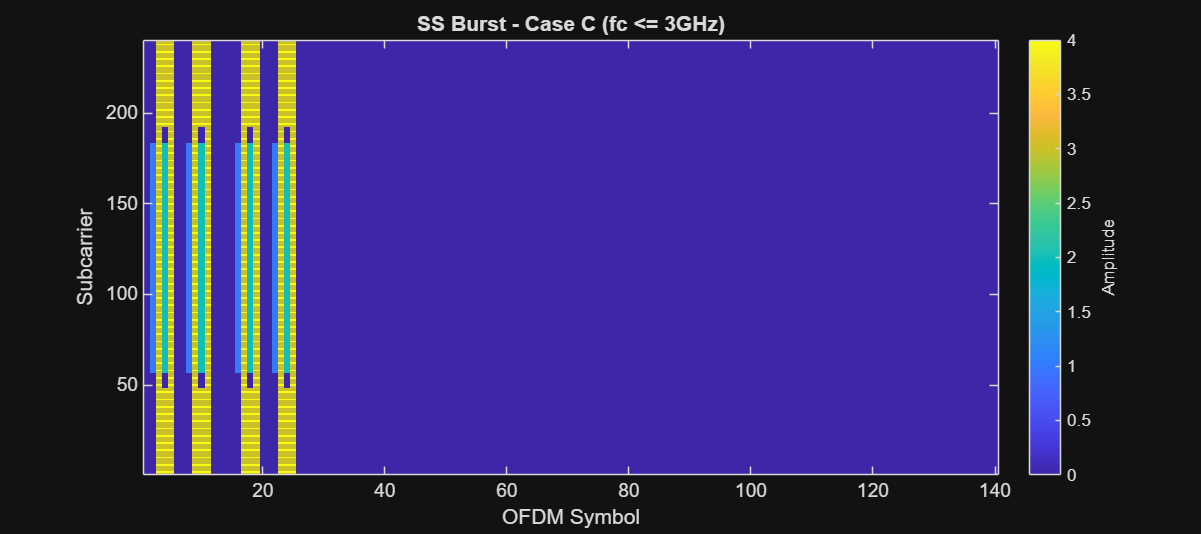

In [16]:

for ssb_index = 1:length(first_symbol_index_ssb)
    v = mod(ssb_index-1, 4);
    issb = mod(ssb_index-1, 4);
    ibar_ssb = issb + 4 * n_hf;

    pbch = nrPBCH(codeword, cellID, v);
    ssb(pbch_indices) = 3 * pbch;

    pbch_dmrs = nrPBCHDMRS(cellID, ibar_ssb);
    ssb(pbch_dmrs_indices) = 4 * pbch_dmrs;

    ss_burst_C1(:, first_symbol_index_ssb(ssb_index) + (0:3)) = ssb;
end

% plot the SS burst
figure('Position', [100 100 900 400])
imagesc(abs(ss_burst_C1));
clim([0 4])
axis xy;
title('SS Burst - Case C (fc <= 3GHz)');
ylabel('Subcarrier');
xlabel('OFDM Symbol');

c = colorbar;
c.Label.String = 'Amplitude';

In [17]:
%{
*----- 3MHz < fc <= 6GHz -----*

Lmax  = 8
v     = 3 LSBs of candidate SS/PBCH block index (TS 38.211 §7.3.3.1)
i_ssb = 3 LSBs of candidate SS/PBCH block index (TS 38.211 §7.4.1.4.1)
n_hf  = 0 as all SSBs are in the first half-frame
n     = 0, 1, 2, 3

%}

mu = 1;
n_subframe = 5;
symbols_per_slot = 14;
total_symbols = symbols_per_slot * 2^mu * n_subframe;
ss_burst_C2 = zeros([240 total_symbols]);

n = [0, 1, 2, 3];
first_symbol_index_ssb = [2; 8;] + 14 * n;
first_symbol_index_ssb = first_symbol_index_ssb(:).'

first_symbol_index_ssb = 1x8
     2     8    16    22    30    36    44    50


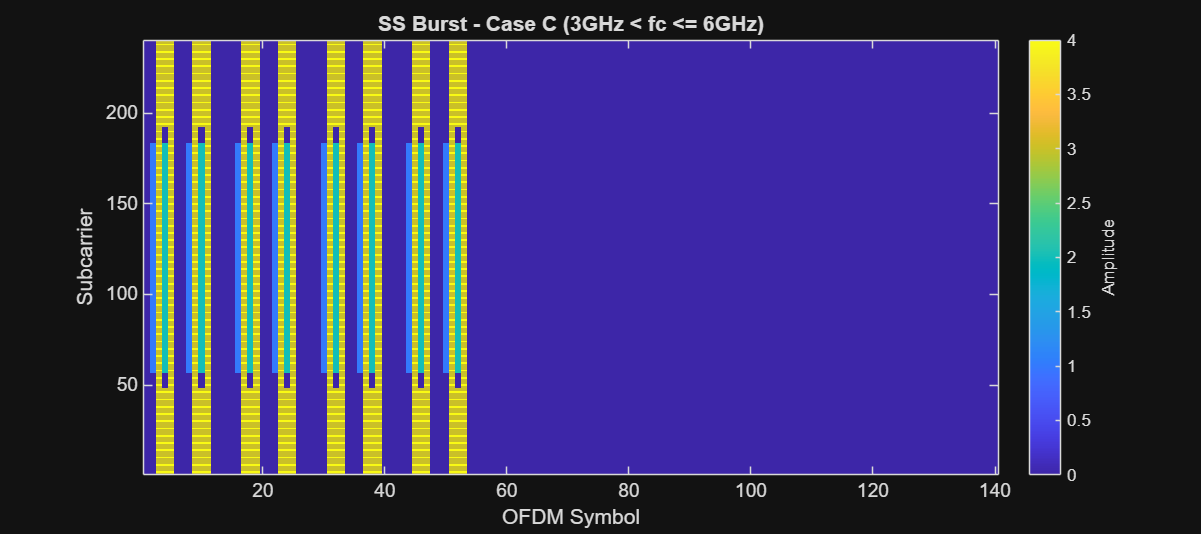

In [18]:

for ssb_index = 1:length(first_symbol_index_ssb)
    v = mod(ssb_index-1, 8);
    issb = v;
    ibar_ssb = issb;

    pbch = nrPBCH(codeword, cellID, v);
    ssb(pbch_indices) = 3 * pbch;

    pbch_dmrs = nrPBCHDMRS(cellID, ibar_ssb);
    ssb(pbch_dmrs_indices) = 4 * pbch_dmrs;

    ss_burst_C2(:, first_symbol_index_ssb(ssb_index) + (0:3)) = ssb;
end

% plot the SS burst
figure('Position', [100 100 900 400])
imagesc(abs(ss_burst_C2));
clim([0 4])
axis xy;
title('SS Burst - Case C (3GHz < fc <= 6GHz)');
ylabel('Subcarrier');
xlabel('OFDM Symbol');

c = colorbar;
c.Label.String = 'Amplitude';

#### Case D \- 120 KHz SCS

The first symbols of the candidate SS/PBCH blocks have indexes: $[4,8,16,20]+28*n$


For carrier frequencies within FR2, $n=0,1,2,3,5,6,7,8,10,11,12,13,15,16,17,18$


In [19]:
%{
*----- fc > 6GHz -----*

Lmax  = 64
v     = 3 LSBs of candidate SS/PBCH block index (TS 38.211 §7.3.3.1)
i_ssb = 3 LSBs of candidate SS/PBCH block index (TS 38.211 §7.4.1.4.1)
n_hf  = 0 as all SSBs are in the first half-frame
n     = 0, 1, 2, 3, 5, 6, 7, 8, 10, 11, 12, 13, 15, 16, 17, 18

%}

mu = 3;
n_subframe = 5;
symbols_per_slot = 14;
total_symbols = symbols_per_slot * 2^mu * n_subframe;
ss_burst_D = zeros([240 total_symbols]);

n = [0, 1, 2, 3, 5, 6, 7, 8, 10, 11, 12, 13, 15, 16, 17, 18];
first_symbol_index_ssb = [4; 8; 16; 20;] + 28 * n;
disp(first_symbol_index_ssb);

     4    32    60    88   144   172   200   228   284   312   340   368   424   452   480   508
     8    36    64    92   148   176   204   232   288   316   344   372   428   456   484   512
    16    44    72   100   156   184   212   240   296   324   352   380   436   464   492   520
    20    48    76   104   160   188   216   244   300   328   356   384   440   468   496   524


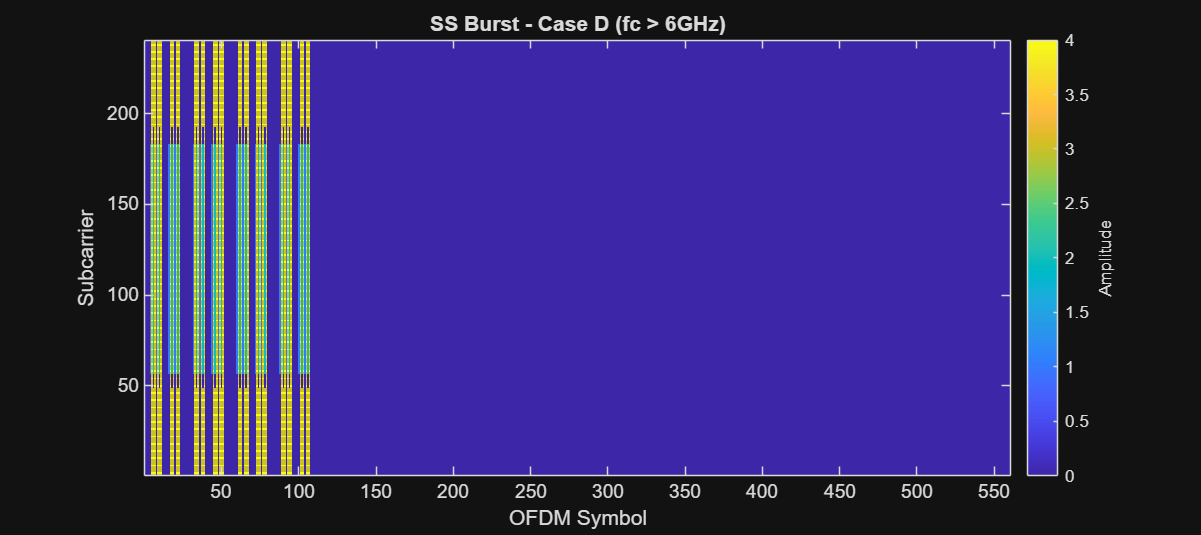

In [20]:

for ssb_index = 1:length(first_symbol_index_ssb)
    v = mod(ssb_index-1, 8);
    issb = v;
    ibar_ssb = issb;

    pbch = nrPBCH(codeword, cellID, v);
    ssb(pbch_indices) = 3 * pbch;

    pbch_dmrs = nrPBCHDMRS(cellID, ibar_ssb);
    ssb(pbch_dmrs_indices) = 4 * pbch_dmrs;

    ss_burst_D(:, first_symbol_index_ssb(ssb_index) + (0:3)) = ssb;
end

% plot the SS burst
figure('Position', [100 100 900 400])
imagesc(abs(ss_burst_D));
clim([0 4])
axis xy;
title('SS Burst - Case D (fc > 6GHz)');
ylabel('Subcarrier');
xlabel('OFDM Symbol');

c = colorbar;
c.Label.String = 'Amplitude';

#### Case E \- 240 KHz SCS

The first symbols of the candidate SS/PBCH blocks have indexes: $[8,12,16,20,32,36,40,44]+56*n$


For carrier frequencies within FR2\-1, $n=0,1,2,3,5,6,7,8$


In [21]:
%{
*----- fc > 6GHz -----*

Lmax  = 64
v     = 3 LSBs of candidate SS/PBCH block index (TS 38.211 §7.3.3.1)
i_ssb = 3 LSBs of candidate SS/PBCH block index (TS 38.211 §7.4.1.4.1)
n_hf  = 0 as all SSBs are in the first half-frame
n     = 0, 1, 2, 3

%}

mu = 4;
n_subframe = 5;
symbols_per_slot = 14;
total_symbols = symbols_per_slot * 2^mu * n_subframe;
ss_burst_E = zeros([240 total_symbols]);

n = [0, 1, 2, 3, 5, 6, 7, 8];
first_symbol_index_ssb = [8; 12; 16; 20; 32; 36; 40; 44;] + 14 * n;
first_symbol_index_ssb = first_symbol_index_ssb(:).'

first_symbol_index_ssb = 1x64
     8    12    16    20    32    36    40    44    22    26    30    34    46    50    54    58    36    40    44    48    60    64    68    72    50    54    58    62    74    78    82    86    78    82    86    90   102   106   110   114    92    96   100   104   116   120   124   128   106   110


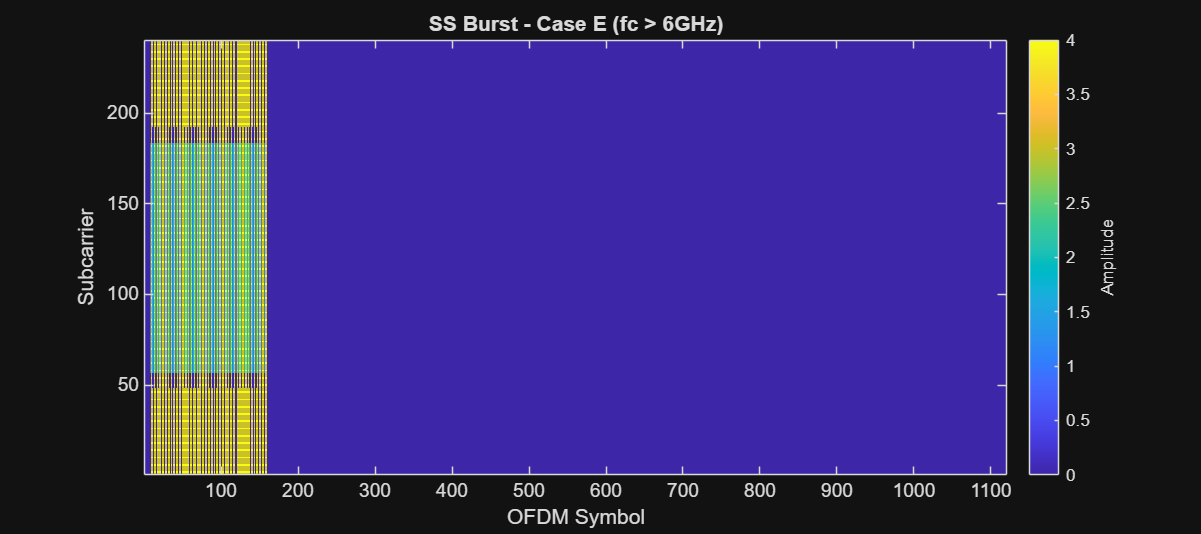

In [22]:
for ssb_index = 1:length(first_symbol_index_ssb)
    v = mod(ssb_index-1, 8);
    issb = v;
    ibar_ssb = issb;

    pbch = nrPBCH(codeword, cellID, v);
    ssb(pbch_indices) = 3 * pbch;

    pbch_dmrs = nrPBCHDMRS(cellID, ibar_ssb);
    ssb(pbch_dmrs_indices) = 4 * pbch_dmrs;

    ss_burst_E(:, first_symbol_index_ssb(ssb_index) + (0:3)) = ssb;
end

% plot the SS burst
figure('Position', [100 100 900 400])
imagesc(abs(ss_burst_E));
clim([0 4])
axis xy;
title('SS Burst - Case E (fc > 6GHz)');
ylabel('Subcarrier');
xlabel('OFDM Symbol');

c = colorbar;
c.Label.String = 'Amplitude';

#### Case F \- 480 KHz SCS

The first symbols of the candidate SS/PBCH blocks have indexes: $[2,9]+14*n$


For carrier frequencies within FR2\-2,       $n=0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31$


In [23]:
%{
*----- fc > 6GHz -----*

Lmax  = 64
v     = 3 LSBs of candidate SS/PBCH block index (TS 38.211 §7.3.3.1)
i_ssb = 3 LSBs of candidate SS/PBCH block index (TS 38.211 §7.4.1.4.1)
n_hf  = 0 as all SSBs are in the first half-frame
n     = 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31

%}

mu = 5;
n_subframe = 5;
symbols_per_slot = 14;
total_symbols = symbols_per_slot * 2^mu * n_subframe;
ss_burst_F = zeros([240 total_symbols]);

n = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31];
first_symbol_index_ssb = [2; 9;] + 14 * n;
first_symbol_index_ssb = first_symbol_index_ssb(:).'

first_symbol_index_ssb = 1x64
     2     9    16    23    30    37    44    51    58    65    72    79    86    93   100   107   114   121   128   135   142   149   156   163   170   177   184   191   198   205   212   219   226   233   240   247   254   261   268   275   282   289   296   303   310   317   324   331   338   345


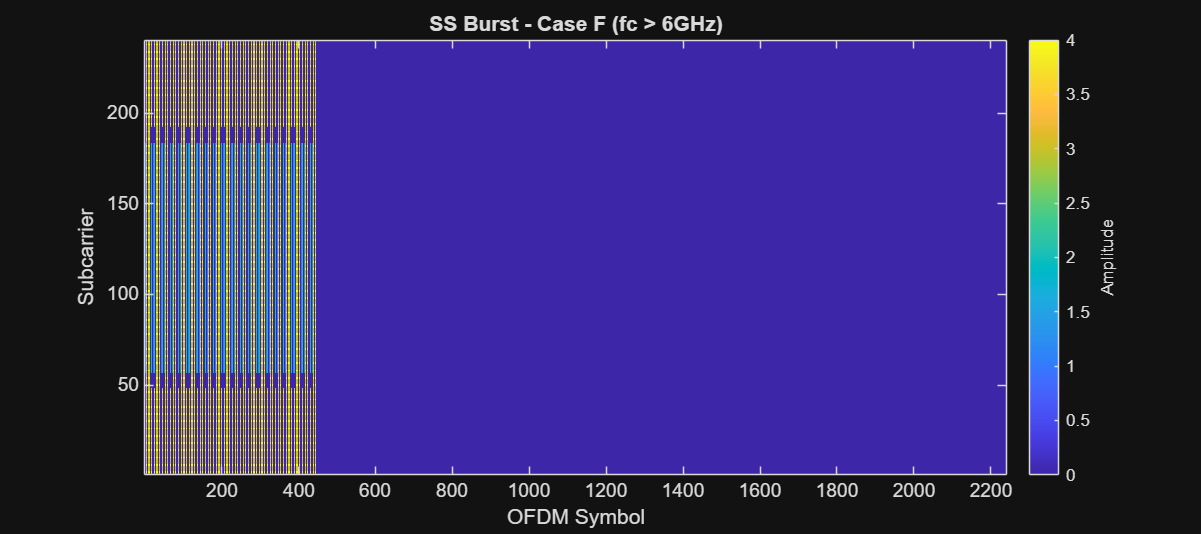

In [24]:
for ssb_index = 1:length(first_symbol_index_ssb)
    v = mod(ssb_index-1, 8);
    issb = v;
    ibar_ssb = issb;

    pbch = nrPBCH(codeword, cellID, v);
    ssb(pbch_indices) = 3 * pbch;

    pbch_dmrs = nrPBCHDMRS(cellID, ibar_ssb);
    ssb(pbch_dmrs_indices) = 4 * pbch_dmrs;

    ss_burst_F(:, first_symbol_index_ssb(ssb_index) + (0:3)) = ssb;
end

% plot the SS burst
figure('Position', [100 100 900 400])
imagesc(abs(ss_burst_F));
clim([0 4])
axis xy;
title('SS Burst - Case F (fc > 6GHz)');
ylabel('Subcarrier');
xlabel('OFDM Symbol');

c = colorbar;
c.Label.String = 'Amplitude';

#### Case G \- 960 KHz SCS

The first symbols of the candidate SS/PBCH blocks have indexes: $[2,9]+14*n$


For carrier frequencies within FR2\-2, $n=0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31$


In [25]:
%{
*----- fc > 6GHz -----*

Lmax  = 64
v     = 3 LSBs of candidate SS/PBCH block index (TS 38.211 §7.3.3.1)
i_ssb = 3 LSBs of candidate SS/PBCH block index (TS 38.211 §7.4.1.4.1)
n_hf  = 0 as all SSBs are in the first half-frame
n     = 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31

%}

mu = 6;
n_subframe = 5;
symbols_per_slot = 14;
total_symbols = symbols_per_slot * 2^mu * n_subframe;
ss_burst_G = zeros([240 total_symbols]);

n = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31];
first_symbol_index_ssb = [2; 9;] + 14 * n;
first_symbol_index_ssb = first_symbol_index_ssb(:).'

first_symbol_index_ssb = 1x64
     2     9    16    23    30    37    44    51    58    65    72    79    86    93   100   107   114   121   128   135   142   149   156   163   170   177   184   191   198   205   212   219   226   233   240   247   254   261   268   275   282   289   296   303   310   317   324   331   338   345


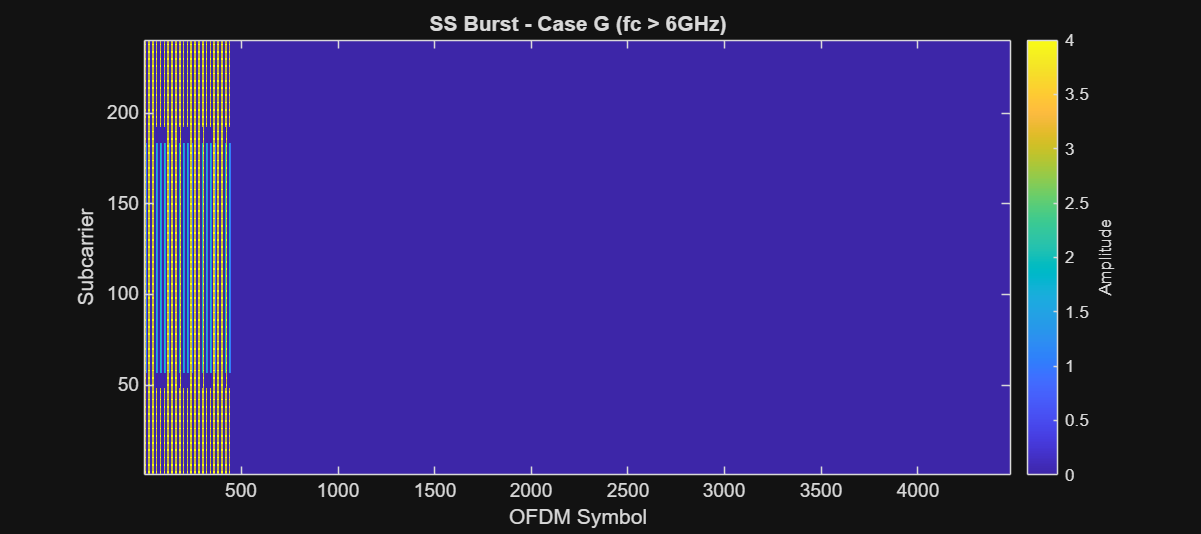

In [26]:

for ssb_index = 1:length(first_symbol_index_ssb)
    v = mod(ssb_index-1, 8);
    issb = v;
    ibar_ssb = issb;

    pbch = nrPBCH(codeword, cellID, v);
    ssb(pbch_indices) = 3 * pbch;

    pbch_dmrs = nrPBCHDMRS(cellID, ibar_ssb);
    ssb(pbch_dmrs_indices) = 4 * pbch_dmrs;

    ss_burst_G(:, first_symbol_index_ssb(ssb_index) + (0:3)) = ssb;
end

% plot the SS burst
figure('Position', [100 100 900 400])
imagesc(abs(ss_burst_G));
clim([0 4])
axis xy;
title('SS Burst - Case G (fc > 6GHz)');
ylabel('Subcarrier');
xlabel('OFDM Symbol');

c = colorbar;
c.Label.String = 'Amplitude';

#### Generate signal containing SS burst and SIB1
-  Define a structure named config to store all transmission parameters.
-  Set the cell identity cellID to uniquely identify the 5G cell.
-  Choose the SS Burst pattern BlockPattern based on the frequency range (Case A, B, C for FR1; Case D, E for FR2).
-  Specify the number of transmitted SSBs using TransmittedBlocks (e.g., ones(1,8) for eight SSBs).
-  Set the subcarrier spacing SubcarrierSpacingCommon for SIB1 (15 or 30 kHz for FR1).
-  Enable or disable SIB1 transmission using EnableSIB1 (1 means enabled).
-  Set the minimum channel bandwidth MinChannelBW (e.g., 5 MHz).
-  Apply a power boost using boost to simulate beamforming (e.g., 6 dB boost for the first SSB).
-  Prepare the waveform configuration using hSIB1WaveformConfiguration(config).
-  Generate the waveform using nrWaveformGenerator(wavegenConfig).
-  Obtain txWaveform (transmitted samples) and waveInfo (waveform details).


In [27]:

% Configure the cell identity
config = struct();
config.NCellID = 102;  % cell ID

% Configure the SS burst parameters for fc > 3GHz so Lmax = 8
config.BlockPattern = 'Case B';         % FR1 options: 'Case A','Case B','Case C'
config.TransmittedBlocks = ones(1,8);   % Bitmap for 8 transmitted SSBs
config.SubcarrierSpacingCommon = 15;    % SIB1 subcarrier spacing in kHz (15 or 30 for FR1)
config.EnableSIB1 = 1;                  % Enable SIB1
config.MinChannelBW = 5;                % Minimum channel bandwidth (MHz)

% Introduce beamforming gain (boost one SSB)
boost = 6;                              % Power boost in dB
config.Power = zeros(size(config.TransmittedBlocks));
config.Power(1) = boost;                % Boost the first SSB

% Configure and generate a waveform containing an SS burst and SIB1
wavegenConfig = hSIB1WaveformConfiguration(config);
[txWaveform, waveInfo] = nrWaveformGenerator(wavegenConfig);
txOfdmInfo = waveInfo.ResourceGrids(1).Info;


### B. Wireless Channel (AWGN)
-  The signal is passed through a wireless channel with Additive White Gaussian Noise (AWGN).
-  $r[n]=x[n]+w[n],$ where $r[n]=$ received signal, $x[n]=$ transmitted signal, $w[n]=$ random noise with Gaussian distribution.

In [28]:
% Add white Gaussian noise to simulate realistic conditions

rng('default');                         % Reset random number generator
SNRdB = 20;                             % Desired SNR in dB
rxWaveform = awgn(txWaveform, SNRdB - boost, -10*log10(double(txOfdmInfo.Nfft)));


### C. Receiver Side


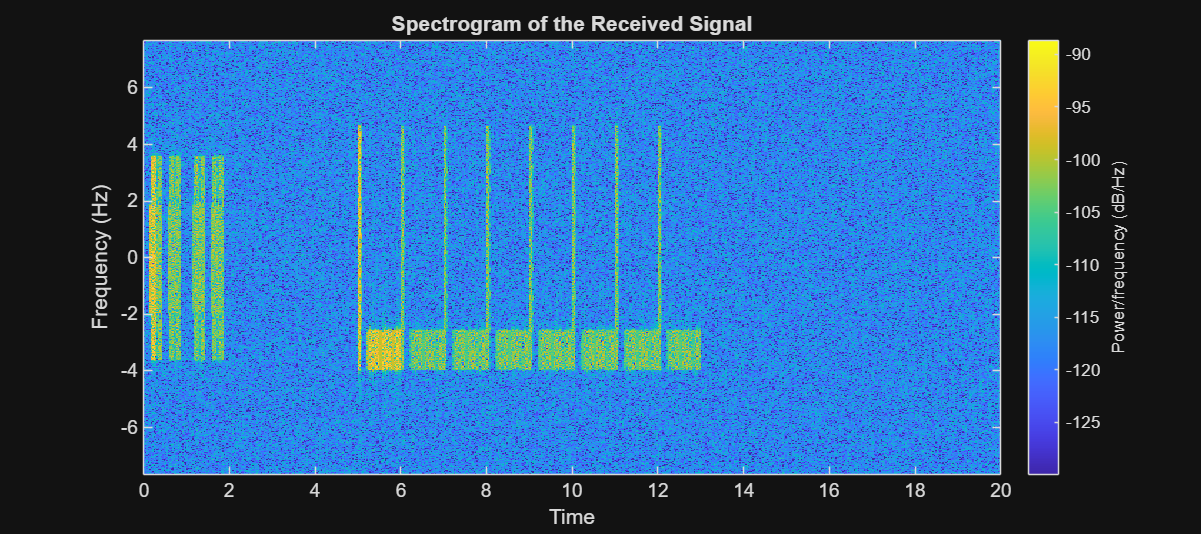

In [29]:

% Receiver parameters
sampleRate = txOfdmInfo.SampleRate;    % Sample rate in samples/second
fPhaseComp = 0;                         % No phase compensation
minChannelBW = config.MinChannelBW;     % Minimum channel bandwidth (MHz)

% Configure burst parameters at receiver
refBurst.BlockPattern = config.BlockPattern;
refBurst.L_max = numel(config.TransmittedBlocks);

% Get OFDM information from the SS burst configuration
nrbSSB = 20;                            % Number of resource blocks in SSB
scsSSB = hSSBurstSubcarrierSpacing(refBurst.BlockPattern);
rxOfdmInfo = nrOFDMInfo(nrbSSB, scsSSB, 'SampleRate', sampleRate);

% Display spectrogram of the received signal
figure('Position', [100 100 900 400])
nfft = rxOfdmInfo.Nfft;
spectrogram(rxWaveform(:,1), ones(nfft,1), 0, nfft, 'centered', sampleRate, 'yaxis', 'MinThreshold', -130);
title('Spectrogram of the Received Signal');
xlabel('Time');
ylabel('Frequency (Hz)');

#### PSS Search and Frequency Offset Correction
-  The receiver first tries a set of possible frequency offsets (shifts) and checks which one makes the PSS pattern line up best with the received signal.
-  The best match tells us three things: (A) the coarse frequency offset, (B) which PSS (NID2 = 0,1,2) was transmitted, and (C) when (time) the PSS occurs.
-  After coarse correction, the receiver refines the frequency offset using the cyclic prefix (CP) of OFDM symbols — the phase of a CP\-based correlation gives a fine frequency estimate.

a. Received signal is multiplied by a rotating phasor:


$$r[n]=s[n]\cdot e^{j2\pi \Delta fnT_s }$$

where

-  $s[n]$ is the transmitted signal
-  $\Delta f$ is the unknown frequency offset (Hz)
-  $Ts=1/fs$ is the sampling period

b. Try many candidate offsets $f_{cand}$ inside a search window (`searchBW`). Candidates are spaced half a subcarrier apart:


$$\textrm{step}=\frac{\Delta f_{sc} }{2}$$

where $\Delta f_{sc}$ is subcarrier spacing. For each candidate $f_{\textrm{cand}}$ we form a frequency\-shifted version of the received signal:


$$r_{\textrm{shift}} [n;f_{\textrm{cand}} ]=r[n]\cdot e^{-j2\pi f_{\textrm{cand}} nT_s }$$

This removes the any trial offset from the received signal.


c. Correlate with PSS \- For each candidate shift and each possible PSS, compute the cross\-correlation:


$$C(f_{\textrm{cand}} ,NID2,\tau )=\sum_{m=0}^{L-1} r_{\textrm{shift}} [m+\tau ;f_{\textrm{cand}} ]\cdot p_{NID2}^* [m]$$

where

-  L is the length of the PSS
-  $\tau$ is a time offset (search position)

The correlation magnitude $|C|$ measures how well the trial\-shifted received signal matches with PSS at time $\tau$.


d. Find the values $(f^{\textrm{cand}} ,N_{\textrm{ID2}} ,\tau )$ which maximizes the funtion:


$$(f^{\textrm{cand}} ,N_{\textrm{ID2}} ,\tau )=\arg \max_{f_{\textrm{cand}} ,N_{\textrm{ID2}} ,\tau } |C(f_{\textrm{cand}} ,N_{\textrm{ID2}} ,\tau )|$$

where

-  ${\hat{f} }$ is the coarse frequency offset estimate
-  ${\hat{N} }_{ID2}$ gives part of the cell ID
-  $\hat{\tau}$ gives the time instant of the strongest SSB

e. Correct the received signal by removing that offset:


$$r_{\textrm{corr}} [n]=r[n]\cdot e^{-j2\pi \hat{f} nT_s }$$

Now the new waveform rx\_wave is frequency\-aligned.



In [30]:

disp(' -- Frequency correction and timing estimation --')

 -- Frequency correction and timing estimation --


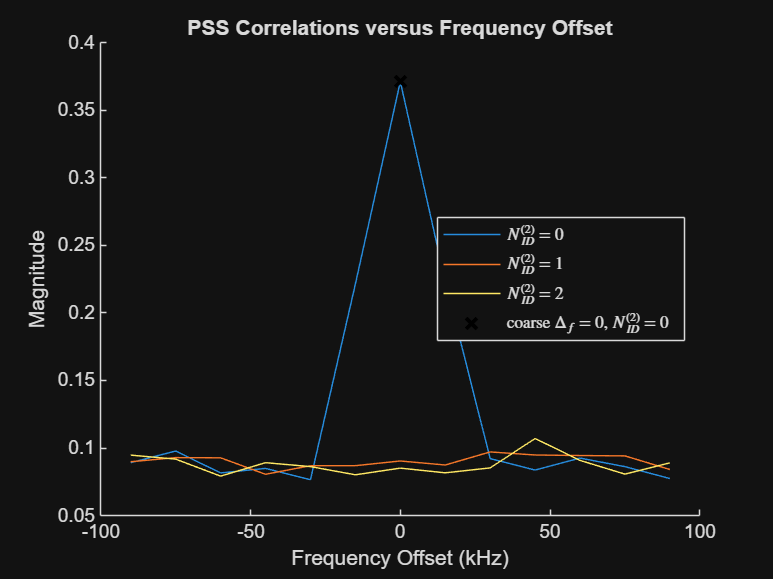

In [31]:

% Specify the frequency offset search bandwidth in kHz
searchBW = 6*scsSSB;
[rxWave,freqOffset,NID2] = hSSBurstFrequencyCorrect(rxWaveform,refBurst.BlockPattern,sampleRate,searchBW);

In [32]:
disp([' Frequency offset: ' num2str(freqOffset,'%.0f') ' Hz'])

 Frequency offset: -16 Hz


#### Time Synchronization and OFDM Demodulation

After detecting the PSS and correcting the frequency offset, the receiver now knows which PSS sequence was transmitted ( $N_{ID}^2$ ) and approximately when the SSB starts in time.


To accurately extract the SSB, the receiver must find the exact symbol boundary \- this process is called time synchronization.


Create a Reference Grid for PSS and  put the PSS sequenc in 2nd symbol. Slide this reference grid over the received waveform (rx\_wave) and computes cross\-correlation between the known PSS sequence and the received samples.


$$R_{rs} [\tau ]=\sum_n r[n]\cdot s^* [n-\tau ]$$

where

-  $r[n]$ is received time\-domain waveform
-  $s[n]$ reference PSS signal (generated locally)

The estimated timing offset is the value of $\tau$ that maximizes correlation:


$$\hat{\tau} =\arg \max_{\tau } |R_{rs} [\tau ]|$$

The receiver now discards the samples before the estimated start of the SSB. It performs OFDM demodulation to convert the time\-domain waveform into the frequency domain grid.


$$X[k]=\sum_{n=0}^{N_{FFT} -1} x[n]e^{-j2\pi \frac{kn}{N_{FFT} }}$$

After demodulation, we extract symbols 2 to 5 since they carry:

-  PSS (symbol 2)
-  SSS (symbol 4)
-  PBCH and PBCH DMRS (symbols 3–5)

In [33]:
% 1: Create a reference grid using the detected PSS

% Each SS Block (SSB) spans 240 subcarriers (20 RBs * 12 subcarriers)
% and 4 OFDM symbols. We use only 2 symbols here to estimate timing.
refGrid = zeros([nrbSSB*12 2]);  % Create an empty grid (frequency x symbols)

% Place the detected PSS sequence (based on NID2) in the 2nd OFDM symbol.
% This avoids issues with the special CP (Cyclic Prefix) length in the 1st symbol.
refGrid(nrPSSIndices,2) = nrPSS(NID2);

% 2: Estimate the timing offset

% nSlot = 0 means we're processing the first slot.
nSlot = 0;

% Estimate where the received waveform aligns with the start of the SS Block.
% 'timingOffset' gives the number of samples from the beginning of rxWave
% to the start of the detected SSB.
timingOffset = nrTimingEstimate(rxWave,nrbSSB,scsSSB,nSlot,refGrid,'SampleRate',sampleRate);

% 3: Synchronize, OFDM-demodulate, and extract the SS Block

% Remove samples before the detected SSB start (synchronization).
% Then, perform OFDM demodulation to get the frequency-domain grid.
rxGrid = nrOFDMDemodulate(rxWave(1+timingOffset:end,:),nrbSSB,scsSSB,nSlot,'SampleRate',sampleRate);

% Extract symbols 2 to 5 which contain PSS, SSS, PBCH, and PBCH DMRS.
rxGrid = rxGrid(:,2:5,:);

% 4: Display timing offset information

% Adjust symbol length to account for receiver sample rate difference.
srRatio = sampleRate/(scsSSB*1e3*rxOfdmInfo.Nfft);
firstSymbolLength = rxOfdmInfo.SymbolLengths(1)*srRatio;

% Display timing offset in both samples and milliseconds.
% This shows how far into the received waveform the SS Block starts.
str = sprintf(' Time offset to synchronization block: %%.0f samples (%%.%.0ff ms) \n',floor(log10(sampleRate))-3);
fprintf(str,timingOffset+firstSymbolLength,(timingOffset+firstSymbolLength)/sampleRate*1e3);

 Time offset to synchronization block: 2200 samples (0.1432 ms)


#### SSS Search

After PSS detection and time synchronization, the receiver must determine the full cell identity (cellID). The receiver already knows $N_{ID}^2$ from PSS detection, so it now determines $N_{ID}^1$ by correlating the received signal with all 336 possible reference SSS sequences.


The correlation is computed as:


$$C(N_{ID}^2 )=\left|\sum_{n=0}^{126} r_{SSS} (n)\cdot {\left(s_{SSS(N_{ID}^2 )}^* (n)\right)}^2 \right|$$

-  $r_{SSS} (n)$ is the received SSS sequence
-  $s_{SSS(N_{ID}^2 )}^* (n)$ is the complex conjugate of the SSS sequence

The strongest peak in correlation indicates the correct $N_{ID}^1$. Complete cell ID is calculated as:


$${\textrm{cellID}}_{\textrm{extracted}} =(3\times N_{ID}^1 )+N_{ID}^2$$



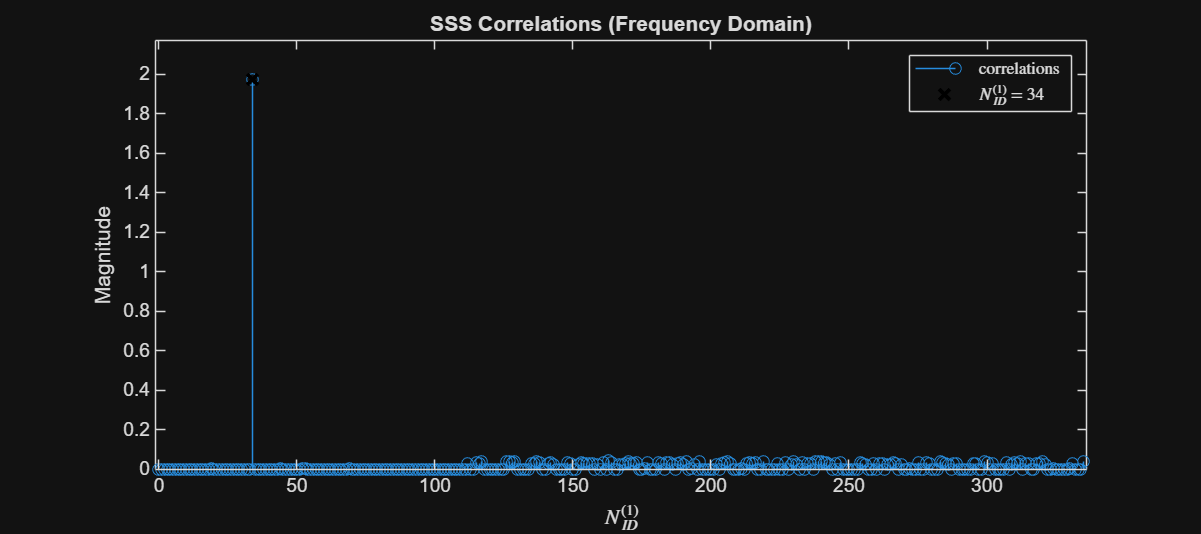

In [34]:
%  SSS Detection and Cell ID Estimation

% 1: Extract the received SSS symbols from the SS/PBCH block
% The SSS (Secondary Synchronization Signal) is located in the 3rd OFDM
% symbol of the SS Block. Use nrSSSIndices to obtain its position and
% extract the corresponding symbols from the received resource grid.
sssIndices = nrSSSIndices;
sssRx = nrExtractResources(sssIndices, rxGrid);

% 2: Perform correlation with all possible SSS sequences
% Each SSS sequence corresponds to a unique NID1 value (0–335).
% For each NID1, generate a reference sequence and compute the
% correlation magnitude with the received SSS symbols.
sssEst = zeros(1, 336);
for NID1 = 0:335
    ncellid = (3 * NID1) + NID2;              % Combine NID1 and NID2
    sssRef = nrSSS(ncellid);                  % Generate reference SSS
    sssEst(NID1 + 1) = sum(abs(mean(sssRx .* conj(sssRef), 1)).^2);
end

% 3: Plot SSS correlation results
% Display correlation magnitudes for all 336 possible NID1 values
% and mark the strongest correlation (detected NID1).
figure('Position', [100 100 900 400])
stem(0:335, sssEst, 'o');
title('SSS Correlations (Frequency Domain)');
xlabel('$N_{ID}^{(1)}$', 'Interpreter', 'latex');
ylabel('Magnitude');
axis([-1 336 0 max(sssEst) * 1.1]);

% Determine NID1 from the maximum correlation value
NID1 = find(sssEst == max(sssEst)) - 1;

% Highlight the detected NID1 on the plot
hold on;
plot(NID1, max(sssEst), 'kx', 'LineWidth', 2, 'MarkerSize', 8);
legend(["correlations" "$N_{ID}^{(1)}$ = " + num2str(NID1)], 'Interpreter', 'latex');

In [35]:

% 4: Compute overall physical cell identity
% Combine the estimated NID1 and previously known NID2 to get the full
% cell ID according to: NCellID = (3 * NID1) + NID2.
ncellid = (3 * NID1) + NID2;

% Display the detected cell ID
disp([' Cell identity: ' num2str(ncellid)])

 Cell identity: 102


#### PBCH DM\-RS search

The receiver tests each possible PBCH DM\-RS pattern (there are 8 possibilities for `ibar_SSB` = 0..7), uses those DM\-RS symbols to estimate the channel and the noise, computes an SNR estimate for each candidate, and selects the candidate with the highest SNR.


The chosen `ibar_SSB` gives the least significant bits of the SS/PBCH block index and is used later for PBCH descrambling and decoding.

-  Generate all possible PBCH DM\-RS sequences.
-  For each candidate PBCH DM\-RS, estimate the channel response and noise level.
-  Determine the signal\-to\-noise ratio for each PBCH DM\-RS candidate.
-  Select the PBCH DM\-RS with the highest SNR.
-  Use the index of the selected PBCH DM\-RS to obtain the least significant bits (LSBs) of the SS/PBCH block index.
-  Initialize PBCH scrambling using the derived SS/PBCH block index.

SNR estimate for that DM\-RS candidate is calculated as:


$$\textrm{dmrsEst}=10\log_{10} \left(\frac{\mathrm{mean}\left(|h_{\textrm{est}} |^2 \right)}{n_{est} }\right)$$

Pick the ${\bar{i} }_{\textrm{SSB}}$ index that gave the highest estimated SNR.


That index is assumed to be the correct PBCH DM\-RS pattern index.



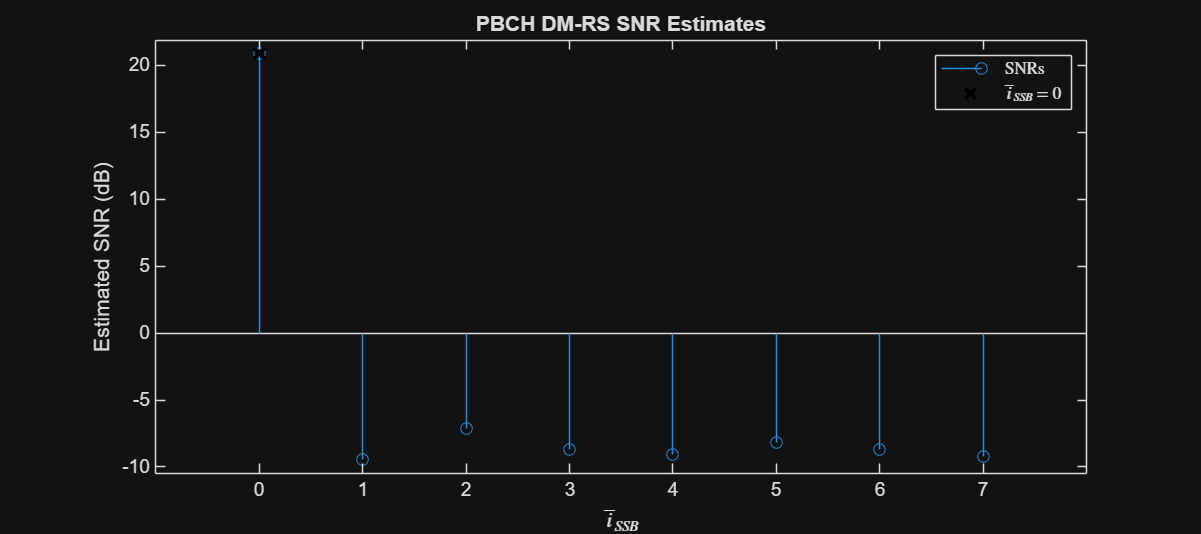

In [36]:
%% PBCH DM-RS Detection and SNR Estimation

% 1: Calculate PBCH DM-RS indices
% The DM-RS (Demodulation Reference Signal) is used for channel estimation
% within the PBCH (Physical Broadcast Channel) symbols.
dmrsIndices = nrPBCHDMRSIndices(ncellid);

% 2: Perform channel estimation for each possible DM-RS sequence
% Loop through all 8 possible ibar_SSB values and estimate SNR for each.
dmrsEst = zeros(1,8);
for ibar_SSB = 0:7

    % Create reference grid and place corresponding DM-RS sequence
    refGrid = zeros([240 4]);
    refGrid(dmrsIndices) = nrPBCHDMRS(ncellid, ibar_SSB);

    % Perform channel estimation using the reference grid
    [hest, nest] = nrChannelEstimate(rxGrid, refGrid, 'AveragingWindow', [0 1]);

    % Compute estimated SNR in dB
    dmrsEst(ibar_SSB+1) = 10 * log10(mean(abs(hest(:).^2)) / nest);

end

% 3: Plot DM-RS SNR estimates
% Visualize the SNR for each ibar_SSB candidate and highlight the best one.
figure('Position', [100 100 900 400])
stem(0:7, dmrsEst, 'o');
title('PBCH DM-RS SNR Estimates');
xlabel('$\overline{i}_{SSB}$','Interpreter','latex');
xticks(0:7);
ylabel('Estimated SNR (dB)');
axis([-1 8 min(dmrsEst)-1 max(dmrsEst)+1]);

% 4: Select ibar_SSB corresponding to highest SNR
% The ibar_SSB index with maximum SNR indicates the correct SS Block.
ibar_SSB = find(dmrsEst == max(dmrsEst)) - 1;

% Highlight the detected ibar_SSB on the plot
hold on;
plot(ibar_SSB, max(dmrsEst), 'kx', 'LineWidth', 2, 'MarkerSize', 8);
legend(["SNRs" "$\overline{i}_{SSB}$ = " + num2str(ibar_SSB)], 'Interpreter', 'latex');


#### Channel Estimation using PBCH DM\-RS and SSS
-  Create a reference grid for the SSB (frequency × symbols).
-  Insert PBCH DM\-RS symbols using the detected ${\bar{i} }_{\textrm{SSB}}$.
-  Insert SSS symbols using the detected ncellid.
-  Perform channel estimation over the combined reference symbols.
-  Obtain the estimated channel (hest), noise variance (nVar), and additional info (hestInfo).

In reference grid, two known sequences are inserted:

-  PBCH DM\-RS: Pilot tones embedded in PBCH for channel estimation.
-  SSS: it helps refine channel estimation because it spans frequency
#### Estimate channel at pilot positions

At every position $(k,n)$ where a reference symbol $s_{\textrm{ref}} (k,n)$ exists, we can directly estimate the channel:


$$\hat{h} (k,n)=\frac{s_{\textrm{ref}} (k,n)}{y(k,n)}$$

where

-  $y(k,n)$ = received complex symbol at subcarrier k, symbol n
-  $s_{\textrm{ref}} (k,n)$ = known transmitted pilot (from DM\-RS or SSS)

This gives channel samples at those pilot locations.


The channel is not only needed at pilot positions, we need it for every resource element (RE) in the SSB to equalize PBCH later. Hence interpolate $\hat{h} (k,n)$ across frequency and time.


The function AveragingWindow smooths over neighboring symbols (time averaging window of 1) to make the estimate less noisy.


Estimate the noise variance ${\hat{\sigma} }_n^2$ and it is derived from how much the received pilot symbols deviate from the expected ones:


$${\hat{\sigma} }_n^2 =\frac{1}{M}\sum_{(k,n)\in I_{\textrm{ref}} } {\left|y(k,n)-{\hat{h} }^{(k,n)} s_{\textrm{ref}} (k,n)\right|}^2$$

If the received symbol perfectly matches the expected pilot, then its low noise variance and if it fluctuates it shows higher noise variance.


In [37]:
%% Channel Estimation using PBCH DM-RS and SSS

% 1: Create a reference grid for channel estimation
% The SS Block spans 240 subcarriers × 4 OFDM symbols.
% This grid will contain both PBCH DM-RS and SSS reference signals.
refGrid = zeros([nrbSSB*12 4]);

% 2: Map PBCH DM-RS sequence into the reference grid
% The DM-RS helps in estimating the channel over the PBCH region.
refGrid(dmrsIndices) = nrPBCHDMRS(ncellid, ibar_SSB);

% 3: Map SSS sequence into the reference grid
% Adding SSS improves channel estimation over synchronization symbols.
refGrid(sssIndices) = nrSSS(ncellid);

% 4: Perform channel estimation
% Estimate the channel frequency response (hest) and noise variance (nVar)
% using the constructed reference grid.
[hest, nVar, hestInfo] = nrChannelEstimate(rxGrid, refGrid, 'AveragingWindow', [0 1]);


#### PBCH demodulation and BCH decoding
-  Extract PBCH symbols from the received SS/PBCH grid.
-  Determine PBCH scrambling parameter v based on ibar\_SSB and L\_max.
-  Extract the estimated channel for PBCH resource elements.
-  Perform MMSE equalization using the channel estimate and noise variance.
-  Plot the equalized PBCH constellation for visualization.
-  Demodulate and decode the PBCH to obtain bit estimates.
-  Calculate and display the RMS PBCH EVM to evaluate demodulation quality.

We have now Cell ID (cellID), channel estimate (h\_est), noise estimate (n\_var) and frequency and timing corrections applied. The receiver can finally demodulate the PBCH and recover the BCH bits, which carry the MIB. The first actual data a UE decodes in a 5G cell.


Extract the PBCH from the received OFDM grid, then with the help of PBCH indices and Lmax detemine the v.


$$v=\textrm{LSBs}\;\textrm{of}\;{\bar{i} }_{\textrm{SSB}}$$

where ${\bar{i} }_{SSB} \in [0,L_{\max } -1]$. This ensures that PBCH sequences transmitted in different SSBs use slightly different scrambling patterns.


The received PBCH symbols $y$ are distorted by the channel $h$ and noise $n$: $y=h\cdot x+n$


To recover $x$, we need to undo the effect of $h$. The Minimum Mean Square Error (MMSE) equalizer is given by:


$$\hat{x} =\frac{h^* }{|h|^2 +\sigma_n^2 }y$$

where:

-  $h^*$ = complex conjugate of h
-  $\sigma_n^2$ = noise variance
-  $\hat{x}$ = equalized (recovered) symbol

This method provides a balance between noise amplification and channel inversion (unlike zero\-forcing).


CSI (output of nrEqualizeMMSE) gives per\-symbol reliability, how strong/clean the signal was after equalization.


In [38]:
%% PBCH Demodulation and BCH Decoding

% 1: Display process start
% Indicate that PBCH demodulation and decoding are starting.
disp(' -- PBCH demodulation and BCH decoding -- ')

 -- PBCH demodulation and BCH decoding --


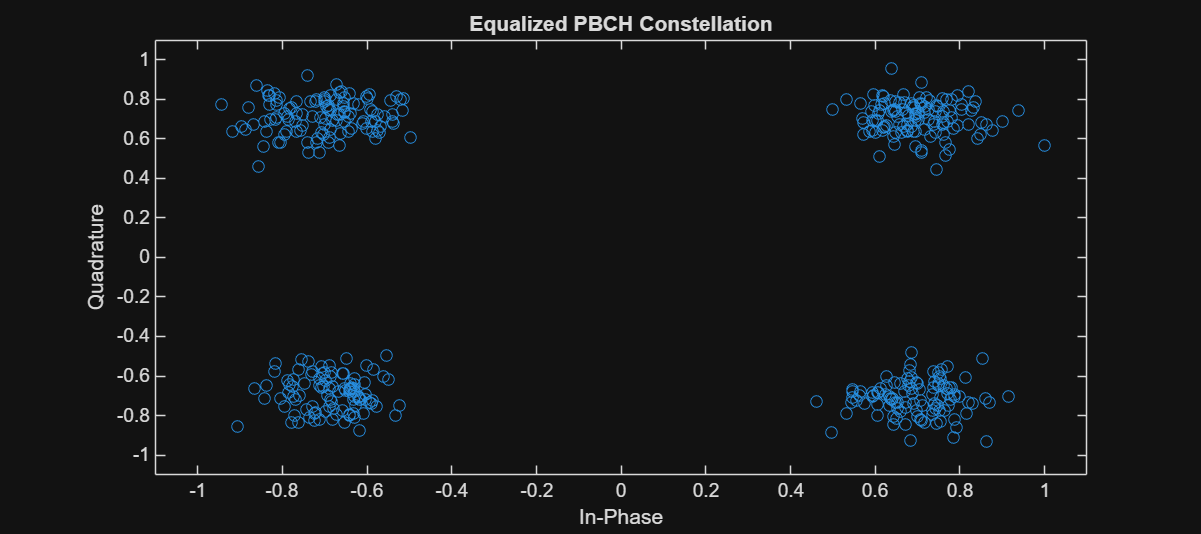

In [39]:

% 2: Extract received PBCH symbols from the SS/PBCH block
% Obtain PBCH resource element indices and extract corresponding symbols
% from the received frequency-domain grid.
[pbchIndices, pbchIndicesInfo] = nrPBCHIndices(ncellid);
pbchRx = nrExtractResources(pbchIndices, rxGrid);

% 3: Configure scrambling parameter 'v' (TS 38.211 Section 7.3.3.1)
% 'v' is determined by the SS/PBCH block index (ibar_SSB) and depends on L_max.
% For L_max = 4, use 2 LSBs; for L_max = 8 or 64, use 3 LSBs.
if refBurst.L_max == 4
    v = mod(ibar_SSB, 4);
else
    v = ibar_SSB;
end
ssbIndex = v;

% 4: Perform PBCH equalization and compute CSI
% Extract channel estimates corresponding to PBCH symbols and perform
% MMSE equalization to obtain compensated PBCH symbols.
pbchHest = nrExtractResources(pbchIndices, hest);
[pbchEq, csi] = nrEqualizeMMSE(pbchRx, pbchHest, nVar);

% Determine modulation order (Qm) and reshape CSI accordingly
Qm = pbchIndicesInfo.G / pbchIndicesInfo.Gd;
csi = repmat(csi.', Qm, 1);
csi = reshape(csi, [], 1);

% 5: Plot equalized PBCH constellation
% Display the PBCH constellation after equalization for quality inspection.
figure('Position', [100 100 900 400]);
plot(pbchEq, 'o');
xlabel('In-Phase'); ylabel('Quadrature');
title('Equalized PBCH Constellation');
m = max(abs([real(pbchEq(:)); imag(pbchEq(:))])) * 1.1;
axis([-m m -m m]);

In [40]:

% 6: Perform PBCH demodulation
% Demodulate the equalized PBCH symbols to recover the encoded bit stream.
pbchBits = nrPBCHDecode(pbchEq, ncellid, v, nVar);

% 7: Compute RMS PBCH EVM (Error Vector Magnitude)
% Compare received and reference PBCH symbols to measure signal quality.
pbchRef = nrPBCH(pbchBits < 0, ncellid, v);
pbchEVMrms = nrEVM(pbchEq, pbchRef) * 100;

% 8: Display PBCH RMS EVM result
% The EVM gives a measure of modulation accuracy in percentage.
disp([' PBCH RMS EVM: ' num2str(pbchEVMrms, '%0.3f') '%']);

 PBCH RMS EVM: 12.432%


####  BCH decoding
-  Apply channel state information (CSI) from the MMSE equalizer to PBCH bit estimates.
-  Perform BCH decoding: rate recovery, polar decoding, CRC check, descrambling, and separate transport block bits from additional payload bits.
-  Display BCH CRC and stop processing if errors are detected.
-  Use additional payload bits (msb\_idx\_offset) to determine full SSB index or subcarrier offset depending on $L_{max}$.
-  Display the calculated SSB index.

After PBCH demodulation, the receiver has:

-  Soft bit estimates (pbchBits)
-  Channel quality info (csi)
-  Cell ID and SSB index

Now we perform BCH decoding, which gives:

-  The BCH transport block (24 MIB bits)
-  Timing\-related payload bits (like SFN and half\-frame number)
-  Validation via CRC

This converts physical bits (PBCH) → logical system information (BCH).


Multiplying by CSI weights soft bits based on their reliability. Mathematically:


$$L_i^{^{\prime } } =L_i \times w_i$$
#### BCH decoding

1. Rate Recovery: Reconstruct the original codeword length (E = 864 bits for PBCH). Soft bits are rearranged and punctured/repeated appropriately.


2. Polar Decoding: Polar decoding estimates the original bits using Successive Cancellation List (SCL) decoding.


3. CRC Decoding: BCH uses a 24\-bit CRC for integrity checking. After decoding, the CRC is verified.


4. PBCH Descrambling: After successful CRC, PBCH bits are descrambled using the cell ID (cellID) and scrambling parameter v. This restores the original transmitted bit sequence before channel coding.


5. Separate Payload Fields:

-  24 bits \- BCH transport block (trblk) \-> MIB
-  8 bits \- additional timing\-related payload bits (A...A+7)

Identify which SSB within the burst was detected.


For $L_{max}$ = 64 (FR2): $ssbIndex=v+8\cdot (MSBsfromBCH)$


For $L_{max}$ = 4 or 8 (FR1): $k_{SSB} =MSB_{\textrm{offset}} \times 16$



In [41]:
%% BCH Decoding and SS Block Index Recovery

% 1: Apply Channel State Information (CSI)
% Weight the PBCH bits by CSI to improve decoding reliability.
pbchBits = pbchBits .* csi;

% 2: Perform BCH decoding
% Includes rate recovery, polar decoding, CRC check, and PBCH descrambling.
% Also separates 8 additional payload bits (A...A+7):
%   A ... A+3 : 4 LSBs of system frame number (SFN)
%         A+4 : half frame number
%   A+5...A+7 : for L_max=64 → 3 MSBs of SS/PBCH block index
%               for L_max=4 or 8 → A+5 gives MSB of k_SSB
polarListLength = 8;
[~, crcBCH, trblk, sfn4lsb, nHalfFrame, msbidxoffset] = ...
    nrBCHDecode(pbchBits, polarListLength, refBurst.L_max, ncellid);

% 3: Display BCH CRC result
% Shows whether the BCH block passed the CRC check.
disp([' BCH CRC: ' num2str(crcBCH)]);

 BCH CRC: 0

In [42]:

% 4: Stop further processing if CRC check fails
% If BCH contains errors, MIB/SIB1 decoding is skipped.
if crcBCH
    disp(' BCH CRC is not zero.');
    return
end

% 5: Recover SS Block index or subcarrier offset
% Use 'msbidxoffset' to reconstruct k_SSB or ssbIndex depending on L_max.
if refBurst.L_max == 64
    ssbIndex = ssbIndex + (bit2int(msbidxoffset, 3) * 8);
    k_SSB = 0;
else
    k_SSB = msbidxoffset * 16;
end

% 6: Display final SSB index
% Indicates which SS Block within the burst was detected.
disp([' SSB index: ' num2str(ssbIndex)]);

 SSB index: 0


#### MIB and BCH Parsing
-  Parse MIB from BCH transport block.
-  Combine MIB bits with PBCH payload to reconstruct 10\-bit SFN.
-  Determine subcarrier offset k\_SSB
-  Build initialSystemInfo structure (cell\-wide parameters)
-  Display decoded MIB content
-  Verify if CORESET 0 is available for further system access

1. The 24\-bit BCH transport block trblk consists of:

-  1 leading bit → message type (0 = valid MIB, 1 = empty / no MIB)
-  23 remaining bits → actual MIB contents (bits 2\-24 parsed).

2. The MIB provides the 6 MSBs of the 10\-bit SFN, while the PBCH payload provides the 4 LSBs.


3. Subcarrier offset $k_{SSB}$ is calculated as:


$$k_{SSB} =k_{SSB}^{\textrm{MIB}} +16\times k_{SSB}^{\textrm{PBCH}}$$

4. Initial System Information Structure includes:

-  MIB fields (DL bandwidth, SCS, PBCH info, etc.)
-  SFN (from MSB + LSB combination)
-  $k_{SSB}$ (subcarrier offset)
-  Number of transmitted SSBs ( $L_{max}$ )

5. This forms the initialSystemInfo structure — the first level of system configuration known to the UE.


6. CORESET 0 presence check:

-  CORESET 0 is required for Type0\-PDCCH search space (SIB1 decoding).
-  Its availability depends on both the block pattern (Case A/B/C) and kSSBk\_{SSB}kSSB.

7. If CORESET 0 is unavailable, the UE cannot decode SIB1 in this configuration.



In [43]:
%% MIB Parsing and Initial System Information Extraction

% 1: Parse last 23 bits of BCH block into MIB message (ignore leading bit)
mib = fromBits(MIB, trblk(2:end));

% 2: Create structure with complete initial system information
initialSystemInfo = initSystemInfo(mib, sfn4lsb, k_SSB, refBurst.L_max);

% 3: Display parsed MIB content
disp(' BCH/MIB Content:')

 BCH/MIB Content:

In [44]:
disp(initialSystemInfo);

                     NFrame: 0
    SubcarrierSpacingCommon: 15
                      k_SSB: 0
          DMRSTypeAPosition: 3
            PDCCHConfigSIB1: [1x1 struct]
                 CellBarred: 0
       IntraFreqReselection: 0

In [45]:

% 4: Check if CORESET0 for Type0-PDCCH common search space exists
if ~isCORESET0Present(refBurst.BlockPattern, initialSystemInfo.k_SSB)
    fprintf('CORESET 0 is not present (k_SSB > k_SSB_max).\n');
    return
end


#### OFDM Demodulation on Full Bandwidth

After successfully decoding the MIB, the receiver has access to essential configuration parameters \- such as the common subcarrier spacing and k\_ssb\_offset, that allow it to demodulate the full downlink bandwidth supporting CORESET 0.


This step transitions the UE from synchronization\-level demodulation (limited to SSB) to full\-bandwidth OFDM demodulation, preparing it for decoding PDCCH (control) and PDSCH (data) channels.

#### Steps
-  Align CORESET 0 in frequency using k\_SSB
-  Adjust timing to the start of the first valid frame
-  Determine demodulation bandwidth (nrb, scsCommon)
-  Perform full\-bandwidth OFDM demodulation
-  Visualize resource grid and verify alignment

1. Compute Frequency Offset (k\_SSB):


$$\Delta f=k_{SSB} \times f_{scs,SSB}$$

$$k_{\textrm{FreqShift}} =k_{SSB} \cdot scs_{KSSB} \cdot 10^3$$

This frequency offset must be removed before OFDM demodulation of CORESET 0.


2. Apply Frequency Shift Correction:


The SS burst was centered during frequency correction.


However, CORESET 0 may be offset by k\_SSB.


Hence, we apply a complex exponential frequency shift to align the received waveform to the CORESET 0 center frequency.


$$r_{\textrm{corr}} (n)=r(n)\cdot e^{j2\pi \Delta f\frac{n}{f_s }}$$

where

-  $r(n)$ = received samples
-  $f_s$ = sampling rate
-  $\displaystyle \Delta f=k_{SSB} \times f_{scs}$

3. After applying frequency correction, the phase compensation frequency (`fPhaseComp`) used during synchronization must be updated.


4.  Timing Alignment to Frame Origin: Now align the waveform to the first complete frame containing the SSB. This ensures the first OFDM symbol corresponds exactly to the frame origin.


5. Determine CORESET 0 Demodulation Bandwidth: CORESET 0 occupies a specific number of resource blocks (NRB) based on system bandwidth and SCS.


$$BW_{\textrm{demod}} =N_{RB} \times 12\times f_{scs,\textrm{common}}$$

 $f_s <BW_{\textrm{demod}} \;\Rightarrow \;\textrm{cannot}\;\textrm{demodulate}$.


6. Perform OFDM Demodulation: Finally, demodulate the received waveform using the common subcarrier spacing (SCS) to obtain the received resource grid.


$$R[k,m]=\sum_{n=0}^{N_{FFT} -1} r_{\textrm{aligned}} \left(n+m(N_{FFT} +N_{CP} )\right)e^{-j\frac{2\pi }{N_{FFT} }kn}$$

where $R[k,m]$ is the received grid in the frequency domain.




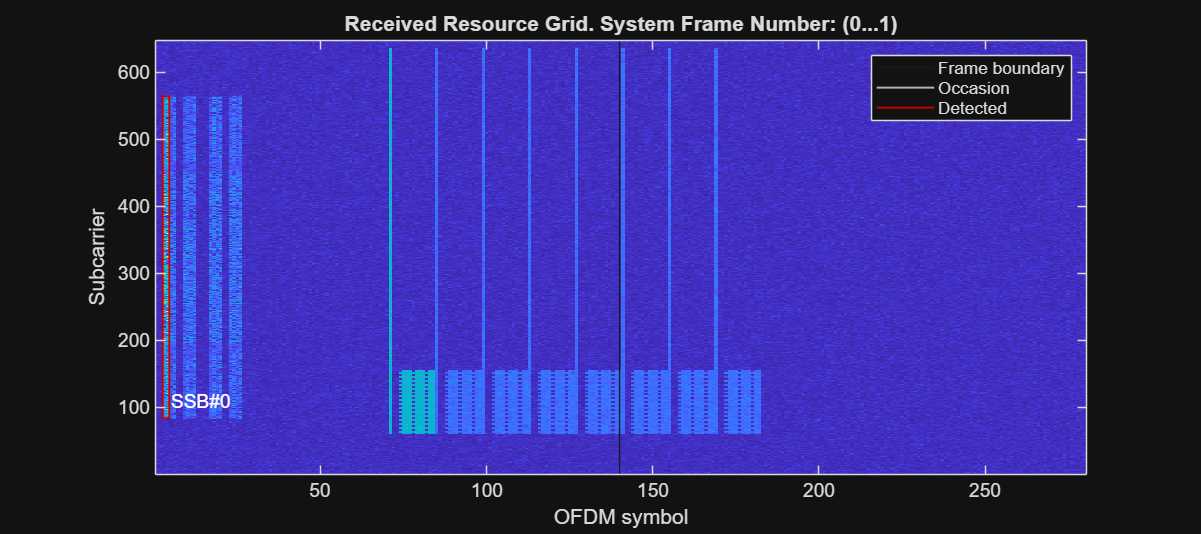

In [46]:
% 1: Get k_SSB from MIB-derived system information
k_SSB = initialSystemInfo.k_SSB;

% 2: Get common subcarrier spacing from system information
scsCommon = initialSystemInfo.SubcarrierSpacingCommon;

% 3: Compute subcarrier spacing for k_SSB
scsKSSB = kSSBSubcarrierSpacing(scsCommon);

% 4: Calculate frequency shift for k_SSB (in Hz)
kFreqShift = k_SSB * scsKSSB * 1e3;

% 5: Apply frequency correction to received waveform
rxWave = rxWave .* exp(1i * 2 * pi * kFreqShift * (0:length(rxWave)-1)' / sampleRate);

% 6: Adjust phase compensation frequency after frequency shift
fPhaseComp = fPhaseComp - kFreqShift;

% 1: Compute frame offset and number of leading frames
[frameOffset, nLeadingFrames] = hTimingOffsetToFirstFrame(timingOffset, refBurst, ssbIndex, nHalfFrame, sampleRate);

% 2: Add leading zeros based on frame offset
zeroPadding = zeros(-min(frameOffset, 0), size(rxWave, 2));
rxWave = [zeroPadding; rxWave(1 + max(frameOffset, 0):end, :)];

% 3: Determine CORESET 0 demodulation bandwidth (NRBs) and SCS
nrb = hCORESET0DemodulationBandwidth(initialSystemInfo, scsSSB, minChannelBW);

% 4: Check if sampling rate is sufficient for CORESET 0 demodulation
if sampleRate < nrb * 12 * scsCommon * 1e3
    disp(['SIB1 recovery cannot continue. CORESET 0 resources are beyond ' ...
          'the frequency limits of the received waveform for the sampling rate configured.']);
    return;
end

% 5: Perform OFDM demodulation using common subcarrier spacing
nSlot = 0;
rxGrid = nrOFDMDemodulate(rxWave, nrb, scsCommon, nSlot, ...
                          'SampleRate', sampleRate, 'CarrierFrequency', fPhaseComp);

% 6: Plot OFDM resource grid and highlight the strongest SS block
plotResourceGrid(rxGrid, refBurst, initialSystemInfo, nLeadingFrames, ssbIndex, nHalfFrame);

#### Demodulation of PDCCH and Downlink Control Information Decoding

To find and decode the DCI Format 1\_0 messages carrying PDSCH scheduling for SIB1.

-  Determine PDCCH monitoring occasions (slots and OFDM symbols) relative to the detected SS block.
-  Extract the subset of the OFDM resource grid that contains CORESET 0 monitoring resources.
-  Configure CORESET 0 and Type0 search spaces, and generate PDCCH candidate indices.
-  Blind\-decode all PDCCH candidates (all aggregation levels) using SI\-RNTI to identify the correct DCI candidate.
-  If a valid DCI is found (CRC passes), compute PDCCH EVM and proceed to PDSCH decoding.

1. Adjust system frame number for leading frames as: $\textrm{new}\textrm{_}\textrm{SFN}=\big(\textrm{old}\textrm{_}\textrm{SFN}-\textrm{number}\textrm{_}\textrm{of}\textrm{_}\textrm{leading}\textrm{_}\textrm{frames}\big)\textrm{mod}1024$


2. Determine PDCCH monitoring resources – slide the CORESET 0 template (frequency region + symbol offsets) over rx\_grid to locate where to look for PDCCH.


3. Extract the relevant resource elements (slots × symbols × antenna) that contain the strongest PDCCH candidates.


4. Configure PDCCH / CORESET 0 / carrier – set up CORESET 0 and the search pattern according to the parameters in initial\_system\_info and ssb\_index.


5. Create DCI format description (SI\-RNTI / Format 1\_0).


6. Once CORESET 0 is configured, the UE blindly searches for a valid DCI message transmitted on the PDCCH.


7. Since the UE doesn’t know exactly where (in frequency, time, or aggregation level) the DCI resides, it must monitor all possible candidates defined by the standard (TS 38.213 §10.1).


8. The function hPDCCH0MonitoringResources() gives a list of monitoring slots (mon\_slots) where CORESET 0 could carry a control message.


9. For each monitoring slot:

-  Set the slot index in the carrier object.
-  Extract the corresponding section of the received OFDM grid.
-  This grid segment contains all resource elements (REs) potentially belonging to the PDCCH within that slot.

9. If CRC passes, you’ve found DCI Format 1\_0; compute PDCCH EVM and proceed to PDSCH / SIB1 decoding.



In [47]:
% 1: Update system frame number with offset due to leading frames
initialSystemInfo.NFrame = mod(initialSystemInfo.NFrame - nLeadingFrames, 1024);

% 2: Get total symbols in received grid
numRxSym = size(rxGrid, 2);

% 3: Compute CORESET 0 monitoring resources (subcarriers, slots, symbols)
[csetSubcarriers, monSlots, monSlotsSym, ssStartSym] = ...
    hPDCCH0MonitoringResources(initialSystemInfo, scsSSB, minChannelBW, ssbIndex, numRxSym);

% 4: Check if search space exceeds waveform duration
if isempty(monSlotsSym)
    disp('Search space slot is beyond end of waveform.');
    return;
end

% 5: Extract monitoring slot grid from received grid
rxMonSlotGrid = rxGrid(csetSubcarriers, monSlotsSym, :);

% 6: Get CORESET and PDCCH configuration for SS block
scsPair = [scsSSB scsCommon];
[pdcch, csetPattern] = hPDCCH0Configuration(ssbIndex, initialSystemInfo, scsPair, ncellid, minChannelBW);

% 7: Configure carrier for SIB1 bandwidth part (CORESET 0)
carrier = hCarrierConfigSIB1(ncellid, initialSystemInfo, pdcch);

% 8: Configure DCI message format 1_0 with SI-RNTI (TS 38.212 Sec 7.3.1.2.1)
dci = DCIFormat1_0_SIRNTI(pdcch.NSizeBWP);

% 9: Display start of DCI message search
disp(' -- Downlink control information message search in PDCCH -- ');

 -- Downlink control information message search in PDCCH --

In [48]:

% 10: Initialize parameters for DCI search
symbolsPerSlot = 14;
siRNTI = 65535; % TS 38.321 Table 7.1-1
dciCRC = true;
mSlotIdx = 0;

% 11: Loop through all monitoring slots
while (mSlotIdx < length(monSlots)) && dciCRC

    % 12: Update slot number for current monitoring slot
    carrier.NSlot = monSlots(mSlotIdx + 1);

    % 13: Get PDCCH candidates and DM-RS info for current slot
    [pdcchInd, pdcchDmrsSym, pdcchDmrsInd] = nrPDCCHSpace(carrier, pdcch);

    % 14: Extract slot-specific resource grid and normalize it
    rxSlotGrid = rxMonSlotGrid(:, (1:symbolsPerSlot) + symbolsPerSlot*mSlotIdx, :);
    rxSlotGrid = rxSlotGrid / max(abs(rxSlotGrid(:)));

    % 15: Continue only if PDCCH REs are non-zero
    notZero = any(cellfun(@(x) any(rxSlotGrid(x), 'all'), pdcchInd));

    % 16: Loop through all aggregation levels (1–5)
    aLevIdx = 1;
    while (aLevIdx <= 5) && dciCRC && notZero

        % 17: Loop through all candidates at each aggregation level
        cIdx = 1;
        numCandidatesAL = pdcch.SearchSpace.NumCandidates(aLevIdx);
        while (cIdx <= numCandidatesAL) && dciCRC

            % 18: Estimate channel using DM-RS for current candidate
            [hest, nVar, pdcchHestInfo] = nrChannelEstimate(rxSlotGrid, ...
                pdcchDmrsInd{aLevIdx}(:, cIdx), pdcchDmrsSym{aLevIdx}(:, cIdx));

            % 19: Extract and equalize PDCCH symbols using MMSE
            [pdcchRxSym, pdcchHest] = nrExtractResources(pdcchInd{aLevIdx}(:, cIdx), rxSlotGrid, hest);
            pdcchEqSym = nrEqualizeMMSE(pdcchRxSym, pdcchHest, nVar);

            % 20: Decode PDCCH symbols into codeword
            dcicw = nrPDCCHDecode(pdcchEqSym, pdcch.DMRSScramblingID, pdcch.RNTI, nVar);

            % 21: Perform DCI message decoding (Polar decoding)
            polarListLength = 8;
            [dcibits, dciCRC] = nrDCIDecode(dcicw, dci.Width, polarListLength, siRNTI);

            % 22: Display decoded candidate information
            if dciCRC == 0
                disp([' Decoded PDCCH candidate #' num2str(cIdx) ...
                      ' at aggregation level ' num2str(2^(aLevIdx-1))]);
            end
            cIdx = cIdx + 1;
        end
        aLevIdx = aLevIdx + 1;
    end
    mSlotIdx = mSlotIdx + 1;
end

 Decoded PDCCH candidate #1 at aggregation level 8


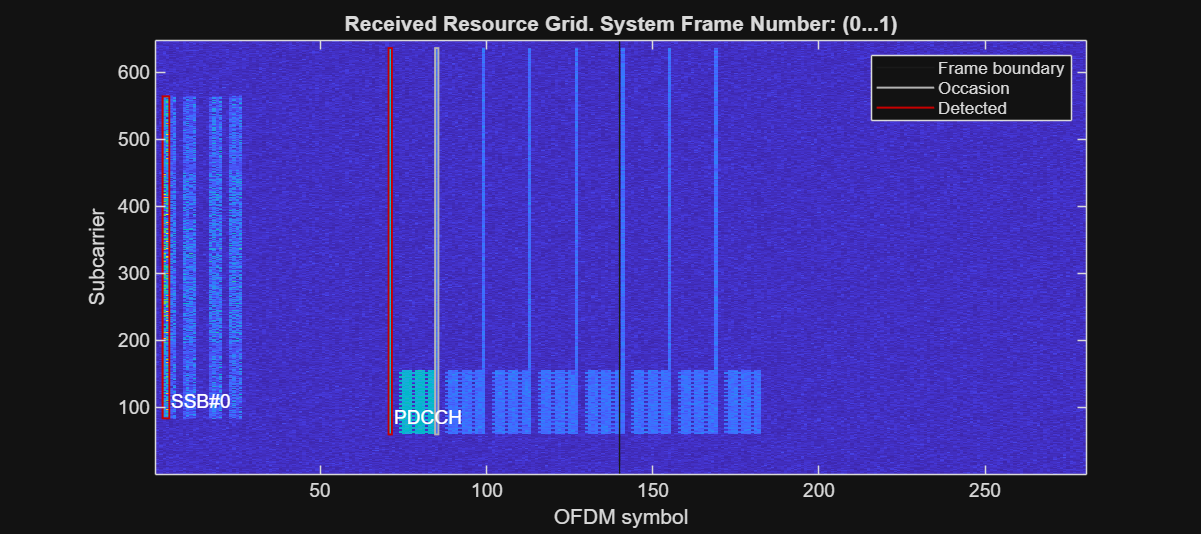

In [49]:

% 23: Update monitoring slot index and symbol positions
mSlotIdx = mSlotIdx - 1;
monSlotsSym = monSlotsSym(mSlotIdx * symbolsPerSlot + (1:symbolsPerSlot));

% 24: Highlight CORESET 0 and SS block locations in resource grid
highlightCORESET0SS(csetSubcarriers, monSlots, monSlots(mSlotIdx + 1), pdcch, dciCRC);

In [50]:

% 25: Stop if DCI decoding failed
if dciCRC
    disp(' DCI decoding failed.');
    return;
end

% 26: Compute RMS PDCCH EVM percentage
pdcchRef = nrPDCCH(double(dcicw < 0), pdcch.DMRSScramblingID, pdcch.RNTI);
pdcchEVMrms = nrEVM(pdcchEqSym, pdcchRef) * 100;

% 27: Display PDCCH EVM and CRC results
disp([' PDCCH RMS EVM: ' num2str(pdcchEVMrms, '%0.3f') '%']);

 PDCCH RMS EVM: 12.339%

In [51]:
disp([' PDCCH CRC: ' num2str(dciCRC)]);

 PDCCH CRC: 0


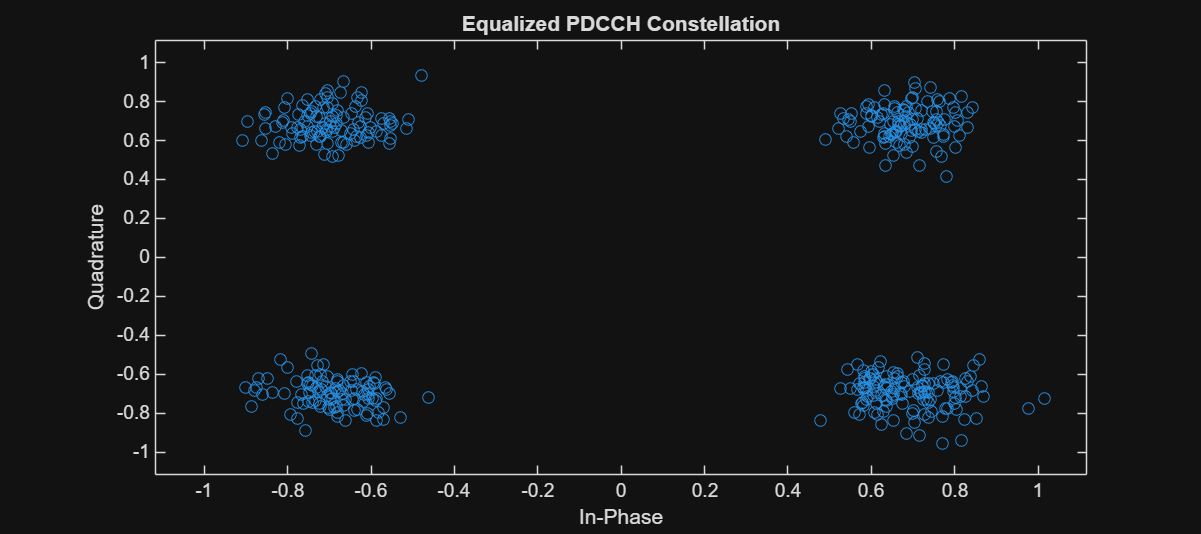

In [52]:

% 28: Plot equalized PDCCH constellation
figure('Position', [100 100 900 400]);
plot(pdcchEqSym, 'o');
xlabel('In-Phase'); ylabel('Quadrature');
title('Equalized PDCCH Constellation');
m = max(abs([real(pdcchEqSym(:)); imag(pdcchEqSym(:))])) * 1.1;
axis([-m m -m m]);

#### Demodulation of PDSCH, Decoding of DL\-SCH and SIB1 Extraction

Receiver performs the following steps to recover SIB1:

-  Build DCI structure from decoded control channel bits.
-  Configure PDSCH using cell ID, BCH info, and DCI parameters.
-  Adjust slot timing if the slot offset $K_0$ indicates PDSCH is in a later slot.
-  Display OFDM grid for visualization of the PDSCH slot (optional).
-  Generate PDSCH DM\-RS indices and symbols for channel estimation.
-  Perform frequency search around the estimated carrier frequency to correct residual frequency offsets.
-  OFDM demodulate the received waveform for each frequency candidate.
-  Normalize received grid to remove magnitude scaling differences.
-  Estimate channel using PDSCH DM\-RS and equalize symbols using MMSE equalization.
-  Demodulate PDSCH symbols to recover the modulated codeword.
-  Configure DL\-SCH decoder with code rate, transport block size, and LDPC decoding settings.
-  Decode DL\-SCH to recover the SIB1 transport block.
-  Check CRC to verify if SIB1 decoding succeeded.
-  Stop frequency search when DL\-SCH CRC passes.
-  Compute EVM (Error Vector Magnitude) to measure signal quality.
-  Display results – PDSCH RMS EVM and DL\-SCH CRC status.

1. The raw DCI bits decoded from PDCCH are converted into a structured DCI message. This DCI contains resource allocation, MCS, and redundancy information for the PDSCH. The receiver extracts PDSCH parameters (modulation, coding rate, PRB allocation, RV, slot offset $K_0$ ) using:


$${\textrm{PDSCH}}_{\textrm{config}} =f(\textrm{DCI},\textrm{BCH}\;\textrm{info},\textrm{Cell}\;\textrm{ID})$$

 $K_0$ determines which slot contains the PDSCH.


2. The PDSCH DMRS is generated and used for estimating the channel response:


$$R^{(k,m)} =\frac{X_{k,m}^{\textrm{DMRS}} }{Y_{k,m}^{\textrm{DMRS}} }$$

3. Frequency correction is applied to compensate CFO:


$$r^{\prime } (n)=r(n)\,e^{-j2\pi f_{\textrm{offset}} \,\frac{n}{f}}$$

OFDM demodulation transforms time\-domain samples to frequency domain:


$$X_{k,m} =\sum_{n=0}^{N-1} r^{\prime } (n+mN)\,e^{-j2\pi kn/N}$$

4. The receiver searches multiple frequencies around $f_{\textrm{PhaseComp}}$:


$$f_{\textrm{search}} =f_{\textrm{PhaseComp}} +\Delta f,~~\Delta f\in \left\lbrack -\frac{B}{2},\,\frac{B}{2}\right\rbrack$$

where $B=2^{\mu } \times 100\,\textrm{kHz},~~\mu =\log_2 \left(\frac{\textrm{SCS}}{15}\right)$


5. Using DMRS\-based estimation, the MMSE equalizer computes:


$${\hat{X} }^{k,m} =\frac{H_{k,m}^* }{|H_{k,m} |^2 +\sigma_n^2 /\sigma_x^2 }\,Y_{k,m}$$

6. The equalized complex symbols are demodulated into bits based on modulation order (e.g., QPSK, 16QAM, 64QAM).


7. DL\-SCH Decoding

-  The codeword is rate\-recovered and LDPC\-decoded.
-  The Transport Block Size (TBS) is calculated.
-  CRC is checked. If CRC = 0 → decoding success.

8. Once DL\-SCH decoding passes CRC, the SIB1 bits are extracted. These bits carry system configuration.


9. Error Vector Magnitude (EVM) measures demodulation accuracy:


$${\mathrm{EVM}}_{\mathrm{RMS}} =100\times \sqrt{\frac{\sum_{k,m} {\left|X_{k,m}^{\textrm{ref}} -{\hat{X} }_{k,m} \right|}^2 }{\sum_{k,m} {\left|X_{k,m}^{\textrm{ref}} \right|}^2 }}$$


In [53]:

% 1: Build the DCI message structure from decoded DCI bits
dci = fromBits(dci, dcibits);

% 2: Configure PDSCH parameters using DCI, CORESET, and BCH information
[pdsch, K0] = hSIB1PDSCHConfiguration(dci, pdcch.NSizeBWP, ...
    initialSystemInfo.DMRSTypeAPosition, csetPattern);

% 3: Update slot number based on K0 offset from DCI message
carrier.NSlot = carrier.NSlot + K0;
monSlotsSym = monSlotsSym + symbolsPerSlot * K0;

% 4: If K0 > 0, plot OFDM grid showing PDSCH slot location
if K0 > 0
    figure;
    imagesc(abs(rxGrid(csetSubcarriers, monSlotsSym, 1))); axis xy;
    xlabel('OFDM symbol');
    ylabel('Subcarrier');
    title('Slot Containing PDSCH (Slot Offset K_0 = 1)');
end

% 5: Generate PDSCH DM-RS indices for channel estimation
pdschDmrsIndices = nrPDSCHDMRSIndices(carrier, pdsch);

% 6: Generate reference PDSCH DM-RS symbols
pdschDmrsSymbols = nrPDSCHDMRS(carrier, pdsch);


In [54]:
% 1: Display current processing stage
disp(' -- PDSCH demodulation and DL-SCH decoding -- ')

 -- PDSCH demodulation and DL-SCH decoding --


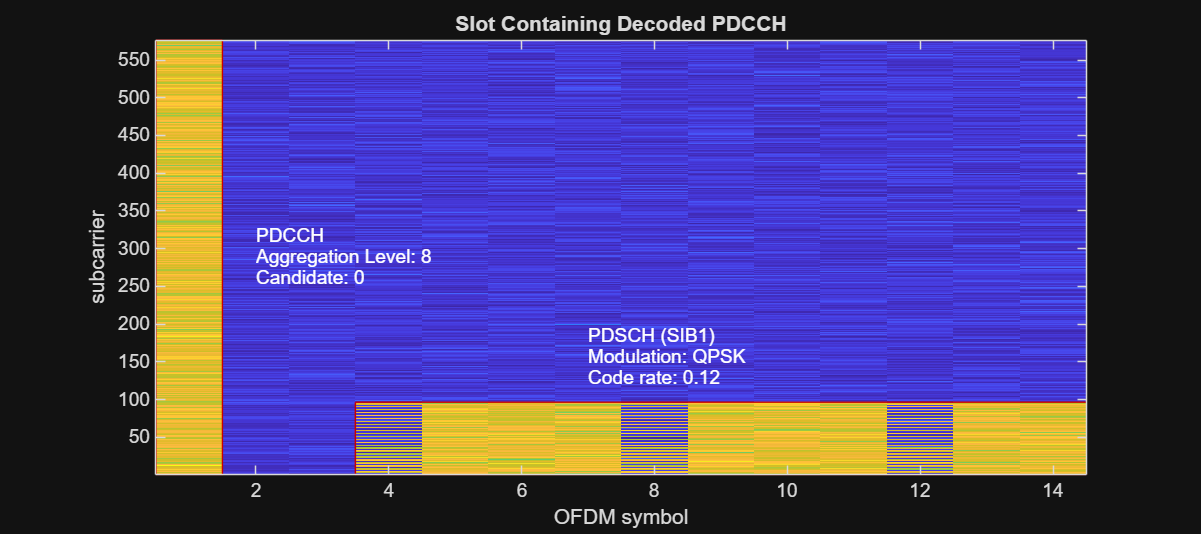

In [55]:

% 2: Define frequency search parameters for fine frequency correction
mu = log2(scsCommon/15);
bw = 2^mu * 100;            % Bandwidth to search (kHz)
freqStep = 2^mu;            % Step size (kHz)
freqSearch = -bw/2 : freqStep : bw/2 - freqStep;
[~, fSearchIdx] = sort(abs(freqSearch));  % Prioritize center frequencies
freqSearch = freqSearch(fSearchIdx);

% 3: Loop over frequency offsets for fine frequency compensation
for fpc = fPhaseComp + 1e3 * freqSearch

    % 4: OFDM demodulate received waveform with adjusted carrier frequency
    nSlot = 0;
    rxGrid = nrOFDMDemodulate(rxWave, nrb, scsCommon, nSlot, ...
                              'SampleRate', sampleRate, 'CarrierFrequency', fpc);

    % 5: Extract and normalize the monitoring slot grid
    rxSlotGrid = rxGrid(csetSubcarriers, monSlotsSym, :);
    rxSlotGrid = rxSlotGrid / max(abs(rxSlotGrid(:)));

    % 6: Estimate channel using PDSCH DM-RS and perform equalization
    [hest, nVar, pdschHestInfo] = nrChannelEstimate(rxSlotGrid, pdschDmrsIndices, pdschDmrsSymbols);
    [pdschIndices, pdschIndicesInfo] = nrPDSCHIndices(carrier, pdsch);
    [pdschRxSym, pdschHest] = nrExtractResources(pdschIndices, rxSlotGrid, hest);
    pdschEqSym = nrEqualizeMMSE(pdschRxSym, pdschHest, nVar);

    % 7: Demodulate the PDSCH symbols to generate codeword
    cw = nrPDSCHDecode(carrier, pdsch, pdschEqSym, nVar);

    % 8: Configure DL-SCH decoder parameters (rate, TBS, and modulation)
    decodeDLSCH = nrDLSCHDecoder;
    decodeDLSCH.LDPCDecodingAlgorithm = 'Normalized min-sum';
    Xoh_PDSCH = 0;  % TS 38.214 Section 5.1.3.2
    mcsTables = nrPDSCHMCSTables;
    qam64Table = mcsTables.QAM64Table; % Use 64QAM MCS table
    tcr = qam64Table.TargetCodeRate(qam64Table.MCSIndex == dci.ModulationCoding);
    NREPerPRB = pdschIndicesInfo.NREPerPRB;
    tbsLength = nrTBS(pdsch.Modulation, pdsch.NumLayers, ...
                      length(pdsch.PRBSet), NREPerPRB, tcr, Xoh_PDSCH);
    decodeDLSCH.TransportBlockLength = tbsLength;
    decodeDLSCH.TargetCodeRate = tcr;

    % 9: Decode DL-SCH transport block and check CRC
    [sib1bits, sib1CRC] = decodeDLSCH(cw, pdsch.Modulation, pdsch.NumLayers, dci.RedundancyVersion);

    % 10: Exit frequency search if SIB1 CRC passes
    if sib1CRC == 0
        break;
    end
end

% 11: Highlight PDSCH and DM-RS resources on the grid
pdcch.AggregationLevel = 2^(aLevIdx-2);
pdcch.AllocatedCandidate = cIdx-1;
plotResourceGridSIB1(rxSlotGrid, carrier, pdcch, pdsch, tcr, K0);


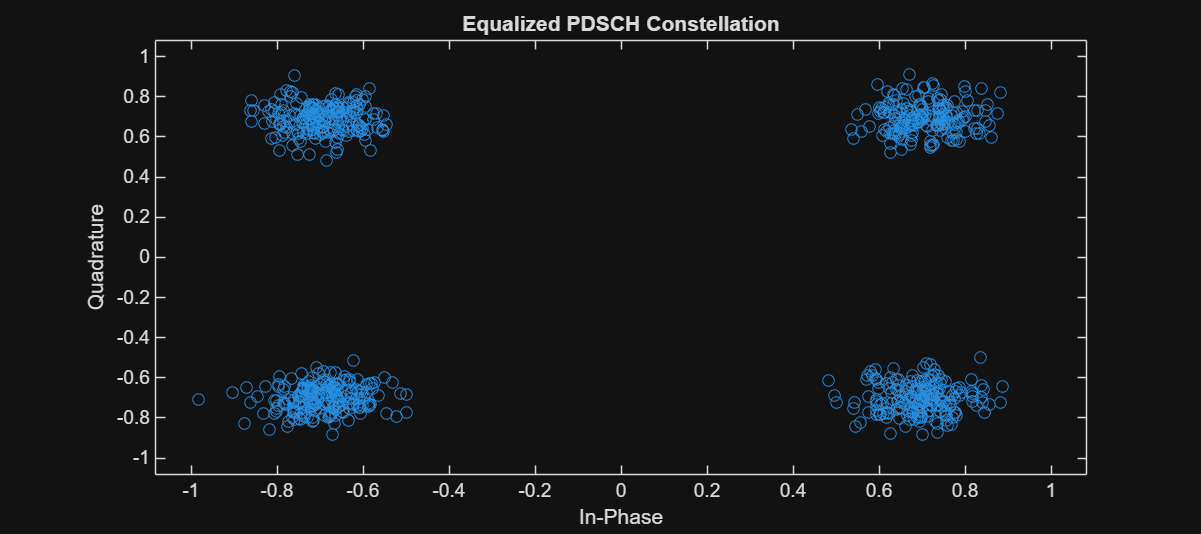

In [56]:

% 12: Plot constellation of equalized PDSCH symbols
figure('Position', [100 100 900 400]);
plot(pdschEqSym, 'o');
xlabel('In-Phase'); ylabel('Quadrature');
title('Equalized PDSCH Constellation');
m = max(abs([real(pdschEqSym(:)); imag(pdschEqSym(:))])) * 1.1;
axis([-m m -m m]);

In [57]:

% 13: Compute RMS EVM (%) of PDSCH including DM-RS power normalization
pdschRef = nrPDSCH(carrier, pdsch, double(cw{1} < 0));
pdschEVMrms = nrEVM(pdschEqSym / sqrt(var(pdschEqSym)), pdschRef) * 100;

% 14: Display final PDSCH EVM and DL-SCH CRC status
disp([' PDSCH RMS EVM: ' num2str(pdschEVMrms, '%0.3f') '%']);

 PDSCH RMS EVM: 10.277%

In [58]:
disp([' PDSCH CRC: ' num2str(sib1CRC)]);

 PDSCH CRC: 0

In [59]:

% 15: Report SIB1 decoding result
if sib1CRC == 0
    disp(' SIB1 decoding succeeded.');
else
    disp(' SIB1 decoding failed.');
end

 SIB1 decoding succeeded.